<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Themes seaborn et matplotlib
sns.set_style('whitegrid') 
plt.figure(figsize=(8, 6.5))
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = ['Segoe UI Emoji', 'Segoe UI Symbol', 'Arial']
sns.set_context('notebook')    

<Figure size 800x650 with 0 Axes>

In [3]:
pd.__version__

'3.0.0'

In [4]:
# Importation du fichier population.csv
population = pd.read_csv('population.csv')

# Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

# Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

# Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'population.csv'

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
# Afficher les dimensions du dataset
print('Le tableau comporte {} observation(s) ou article(s)'.format(population.shape[0]))
print('Le tableau comporte {} colonne(s)'.format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
# Consulter le nom des colonnes(nombre présent au-dessus)
print('Les colonnes du tableau sont les suivantes : {}'.format(population.columns))
# La nature des données dans chacune des colonnes
print('La nature des données est la suivante : {} '.format(population.dtypes))
# Le nombre de valeurs présentes dans chacune des colonnes
population.info()
population.notna().sum()

Les colonnes du tableau sont les suivantes : Index(['Zone', 'Année', 'Valeur'], dtype='str')
La nature des données est la suivante : Zone          str
Année       int64
Valeur    float64
dtype: object 
<class 'pandas.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   str    
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 33.3 KB


Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [ ]:
# Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [ ]:
# Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
# Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur'] * 1000

In [ ]:
# changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur': 'Population'}, inplace=True)

In [ ]:
# Affichage les 5 premières lignes de la table pour voir les modifications
display(population.head())

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [ ]:
# Verification de l'absence de doublons
population.duplicated().sum()

np.int64(0)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
# Afficher les dimensions du dataset
print('Le tableau comporte {} observation(s) ou article(s)'.format(dispo_alimentaire.shape[0])
)
print('Le tableau comporte {} colonne(s)'.format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [ ]:
# Consulter le nom des colonnes (nombre présent au-dessus)
print(
    'Les colonnes du tableau sont les suivantes : {}'.format(dispo_alimentaire.columns)
)
# La nature des données dans chacune des colonnes
print('La nature des données est la suivante : {} '.format(dispo_alimentaire.dtypes))
# Le nombre de valeurs présentes dans chacune des colonnes
dispo_alimentaire.info()
dispo_alimentaire.notna().sum()

Les colonnes du tableau sont les suivantes : Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='str')
La nature des données est la suivante : Zone                                                                 str
Produit                                                              str
Origine                                                              str
Aliments pour animaux                                            float64
Autres Utilisations                                              flo

Zone                                                             15605
Produit                                                          15605
Origine                                                          15605
Aliments pour animaux                                             2720
Autres Utilisations                                               5496
Disponibilité alimentaire (Kcal/personne/jour)                   14241
Disponibilité alimentaire en quantité (kg/personne/an)           14015
Disponibilité de matière grasse en quantité (g/personne/jour)    11794
Disponibilité de protéines en quantité (g/personne/jour)         11561
Disponibilité intérieure                                         15382
Exportations - Quantité                                          12226
Importations - Quantité                                          14852
Nourriture                                                       14015
Pertes                                                            4278
Produc

In [ ]:
# Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [ ]:
# multiplication de toutes les lignes contenant des milliers de tonnes en Kg
# Utilisation du lexique pour connaître les colonnes en milliers de tonnes à convertir
d_a_kg = [
    'Aliments pour animaux',
    'Autres Utilisations',
    'Disponibilité intérieure',
    'Exportations - Quantité',
    'Importations - Quantité',
    'Nourriture',
    'Pertes',
    'Production',
    'Semences',
    'Traitement',
    'Variation de stock',
]
dispo_alimentaire[d_a_kg] = dispo_alimentaire[d_a_kg] * 1_000_000

In [ ]:
# Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Verification de l'absence de doublons
dispo_alimentaire.duplicated().sum()

np.int64(0)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
# Afficher les dimensions du dataset
print(
    'Le tableau comporte {} observation(s) ou article(s)'.format(
        aide_alimentaire.shape[0]
    )
)
print('Le tableau comporte {} colonne(s)'.format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
# Consulter le nom des colonnes (nombre présent au-dessus)
print(
    'Les colonnes du tableau sont les suivantes : {}'.format(aide_alimentaire.columns)
)
# La nature des données dans chacune des colonnes
print('La nature des données est la suivante : {} '.format(aide_alimentaire.dtypes))
# Le nombre de valeurs présentes dans chacune des colonnes
aide_alimentaire.info()
aide_alimentaire.notna().sum()

Les colonnes du tableau sont les suivantes : Index(['Pays bénéficiaire', 'Année', 'Produit', 'Valeur'], dtype='str')
La nature des données est la suivante : Pays bénéficiaire      str
Année                int64
Produit                str
Valeur               int64
dtype: object 
<class 'pandas.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Pays bénéficiaire  1475 non-null   str  
 1   Année              1475 non-null   int64
 2   Produit            1475 non-null   str  
 3   Valeur             1475 non-null   int64
dtypes: int64(2), str(2)
memory usage: 46.2 KB


Pays bénéficiaire    1475
Année                1475
Produit              1475
Valeur               1475
dtype: int64

In [ ]:
# Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [ ]:
# changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [ ]:
# Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000

In [ ]:
# Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
# Afficher les dimensions du dataset
print(
    'Le tableau comporte {} observation(s) ou article(s)'.format(
        sous_nutrition.shape[0]
    )
)
print('Le tableau comporte {} colonne(s)'.format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
# Consulter le nom des colonnes (nombre présent au-dessus)
print('Les colonnes du tableau sont les suivantes : {}'.format(sous_nutrition.columns))
# La nature des données dans chacune des colonnes
print('La nature des données est la suivante : {} '.format(sous_nutrition.dtypes))
# Le nombre de valeurs présentes dans chacune des colonnes
sous_nutrition.info()
sous_nutrition.notna().sum()

Les colonnes du tableau sont les suivantes : Index(['Zone', 'Année', 'Valeur'], dtype='str')
La nature des données est la suivante : Zone      str
Année     str
Valeur    str
dtype: object 
<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Zone    1218 non-null   str  
 1   Année   1218 non-null   str  
 2   Valeur  624 non-null    str  
dtypes: str(3)
memory usage: 28.7 KB


Zone      1218
Année     1218
Valeur     624
dtype: int64

In [ ]:
# Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [ ]:
# Conversion de la colonne sous nutrition en numérique
# sous_nutrition['Valeur']=sous_nutrition['Valeur'].astype(float)

In [ ]:
# Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
# Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
sous_nutrition.fillna(0, inplace=True)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5
...,...,...,...
1213,Zimbabwe,2013-2015,0.0
1214,Zimbabwe,2014-2016,0.0
1215,Zimbabwe,2015-2017,0.0
1216,Zimbabwe,2016-2018,0.0


In [ ]:
# changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur': 'Sous Nutrition'}, inplace=True)

In [ ]:
# Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['Sous Nutrition'] = sous_nutrition['Sous Nutrition'] * 1e6

In [ ]:
# Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Sous Nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# Nouveau df correspondant appelé p_sn_2017
# Selon lexique : 2017=2016-2018 dans la table sous_nutrition

p_2017 = population.loc[population['Année'] == 2017, :]
sn_2017 = sous_nutrition.loc[sous_nutrition['Année'] == '2016-2018', :]

p_sn_2017 = pd.merge(p_2017, sn_2017, suffixes=['2017p', '2017sn'], on='Zone', how='left')

del p_sn_2017['Année2017sn']

In [ ]:
# Affichage du dataset
p_sn_2017.head()

,Zone,Année2017p,Population,Sous Nutrition
0,Afghanistan,2017,36296113.0,10500000.0
1,Afrique du Sud,2017,57009756.0,3100000.0
2,Albanie,2017,2884169.0,100000.0
3,Algérie,2017,41389189.0,1300000.0
4,Allemagne,2017,82658409.0,0.0


In [ ]:
# Verification de l'absence de doublons
p_sn_2017.duplicated().sum()

np.int64(0)

In [ ]:
# Calcul et affichage du nombre de personnes en état de sous nutrition
population_totale = p_sn_2017['Population'].sum()
nb_pers_sn = p_sn_2017['Sous Nutrition'].sum()
print(
    f'La population totale en 2017 est de : {population_totale:,.0f} personnes'.replace(
        ',', ' '
    )
)
print(
    f'Le nombre de personnes en état de sous nutrition est de : {nb_pers_sn:,.0f} personnes'.replace(
        ',',' ' 
    )
)

La population totale en 2017 est de : 7 548 134 111 personnes
Le nombre de personnes en état de sous nutrition est de : 535 700 000 personnes


In [ ]:
# proportion de personnes en état de sous nutrition en 2017
proportion_sn = (nb_pers_sn / population_totale) * 100
print(
    f"La proportion de personnes en sous nutrition dans le monde, en 2017, est de : {proportion_sn:.2f}  %"
)

La proportion de personnes en sous nutrition dans le monde, en 2017, est de : 7.10  %


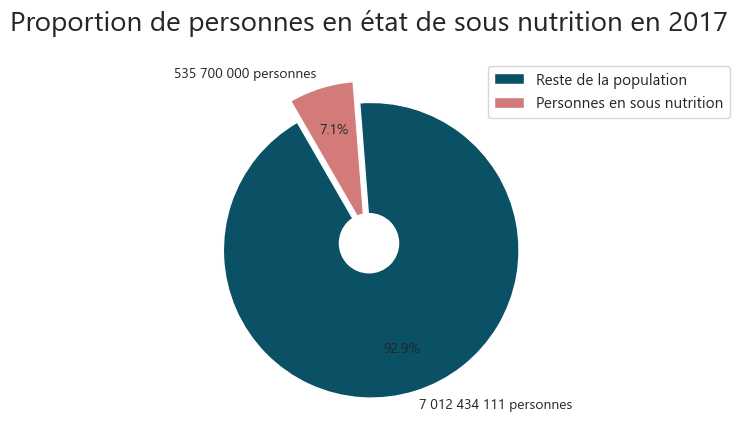

In [ ]:
# Camembert représentant la proportion de personnes en état de sous nutrition en 2017 par rapport à la population totale. 
plt.title(
    'Proportion de personnes en état de sous nutrition en 2017',
    fontsize=20,
    fontweight="bold",
    pad=20,
)

plt.pie(
    [population_totale - nb_pers_sn, nb_pers_sn],
    labels=[f'{population_totale-nb_pers_sn:,.0f} personnes'.replace(',',' '), 
            f'{nb_pers_sn:,.0f} personnes'.replace(',',' ')],
    startangle=120,
    explode=[0.05, 0.1],
    autopct=lambda x: str(round(x, 2)) + "%",
    colors = ["#0A5166", "#D37A7A"],
    pctdistance = 0.7, 
    textprops={'fontsize': 10}
)

centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.legend(['Reste de la population', 'Personnes en sous nutrition'],
    bbox_to_anchor=(0.8,1))

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
# Combien mange en moyenne un être humain ? 2200 kcal
# Source => https://www.anses.fr/fr/content/inca-3-evolution-des-habitudes-et-modes-de-consommation-de-nouveaux-enjeux-en-matiere-de#:~:text=Les%20Fran%C3%A7ais%20consomment%20en%20moyenne,%2C%20dont%2050%25%20de%20boissons.
besoin_kcal_j = 2500

In [ ]:
# On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
# Selection du df p_2017 car dispo_alimentaire concerne uniquement l'année 2017
da_p = pd.merge(dispo_alimentaire, p_2017, on="Zone", how="left")

In [ ]:
# Affichage du nouveau dataframe
da_p.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0


In [ ]:
# Verification de l'absence de doublons
da_p.duplicated().sum()

np.int64(0)

In [ ]:
# Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
da_p["Dispo_kcal"] = (
    da_p["Disponibilité alimentaire (Kcal/personne/jour)"] * da_p["Population"]
)
da_p.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,145184452.0


In [ ]:
# Calcul du nombre d'humains pouvant être nourris
dispo_kcal_tot = da_p["Dispo_kcal"].sum()

p_nourrie = dispo_kcal_tot / besoin_kcal_j

print(
    f"La population totale est de : {population_totale :,.0f} personnes".replace(
        ",", " "
    )
)
print(
    f"La quantité de kcal disponibles par jour dans le monde est de : {dispo_kcal_tot :,.2f} Kcal".replace(
        ",", " "
    )
)
print(
    f"Le nombre de personnes pouvant être nourries est de : {p_nourrie :,.0f} personnes".replace(
        ",", " "
    )
)

La population totale est de : 7 548 134 111 personnes
La quantité de kcal disponibles par jour dans le monde est de : 20 918 984 627 331.00 Kcal
Le nombre de personnes pouvant être nourries est de : 8 367 593 851 personnes


In [ ]:
# Proportion de la population mondiale pouvant être nourrie
proportion_nourrie = (p_nourrie / population_totale) * 100
print(
    f"La proportion de la population mondiale pouvant être nourrie est de : {proportion_nourrie:.2f}  %"
)

La proportion de la population mondiale pouvant être nourrie est de : 110.86  %


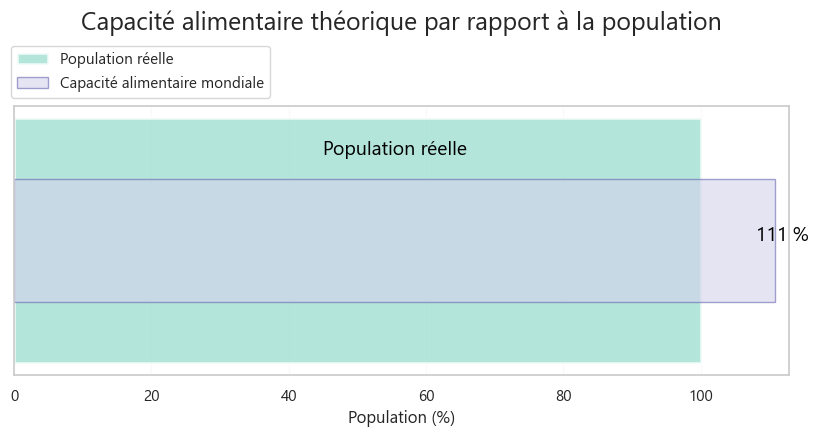

In [ ]:
# Graphique représentant la capacité alimentaire théorique par rapport à la population
population_100 = 100
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.set_title(
    'Capacité alimentaire théorique par rapport à la population', 
    fontsize=18, 
    fontweight='bold', 
    pad=55
    )
             
bars1 = ax.barh(0, 100,           
                height=0.20,
                color="#95DBCC",
                edgecolor='white',
                linewidth=2,                      
                alpha=0.7,         
                label='Population réelle',
                )

bars2 = ax.barh(0, proportion_nourrie,          
                height=0.1, 
                color="#D3D2EB",
                edgecolor="#6866AF",   
                alpha=0.6,
                label='Capacité alimentaire mondiale')

ax.text(
    45, 0.07, 
    'Population réelle', 
    fontweight='bold', 
    fontsize=14, 
    color='black'
    )

ax.text(
    108, 0, 
    f'{proportion_nourrie:.0f} %', 
    fontweight='bold', 
    fontsize=14, 
    color='black'
    )

ax.set_xlabel(
    'Population (%)', 
    fontsize=12
    )

ax.set_xlim(
    0, 
    proportion_nourrie +2
    )

ax.set_yticks([])

plt.legend(bbox_to_anchor=(0.34,1.25))

plt.grid(alpha=0.1)

In [ ]:
display(da_p.head())

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,145184452.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
# création d'un DF propre aux produits végétaux
da_pv=da_p.loc[da_p["Origine"] == "vegetale"]
da_pv.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,145184452.0
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,...,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0


In [ ]:
# Verification de l'absence de doublons
da_pv.duplicated().sum()

np.int64(0)

In [ ]:
# Calcul du nombre de kcal disponibles pour les végétaux
dispo_kcal_vegetaux = (da_pv['Dispo_kcal']).sum()
print(
    f"Le nombre de kcal disponibles (par personne et par jour) en végétaux est de : {dispo_kcal_vegetaux:,.2f} Kcal".replace(
        ",", " "
    )
)

Le nombre de kcal disponibles (par personne et par jour) en végétaux est de : 17 260 764 211 501.00 Kcal


In [ ]:
# Calcul du nombre d'humains pouvant être nourris avec les végétaux
p_nourrie_vegetaux = dispo_kcal_vegetaux / besoin_kcal_j
print(
    f"Le nombre de personnes pouvant être nourries (par jour) est de : {p_nourrie_vegetaux :,.0f} personnes".replace(
        ",", " "
    )
)

Le nombre de personnes pouvant être nourries (par jour) est de : 6 904 305 685 personnes


In [ ]:
# Proportion de la population mondiale pouvant être nourrie avec les végétaux
proportion_nourrie_vegetaux = round((p_nourrie_vegetaux / population_totale) * 100,2)
print(
    f"La proportion de la population mondiale pouvant être nourrie est de : {proportion_nourrie_vegetaux:.0f}  %"
)

La proportion de la population mondiale pouvant être nourrie est de : 91  %


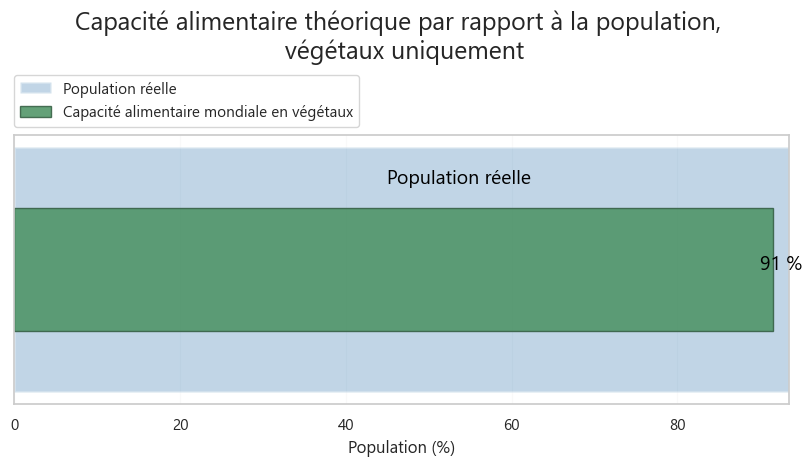

In [ ]:
# Graphique représentant la capacité alimentaire théorique par rapport à la population en végétaux uniquement
population_100 = 100
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.set_title(
    'Capacité alimentaire théorique par rapport à la population, \n végétaux uniquement', 
    fontsize=18, 
    fontweight='bold', 
    pad=55
    )
             
bars1 = ax.barh(0, 100,           
                height=0.20,
                color="#3277AF",
                edgecolor='white',
                linewidth=2,                      
                alpha=0.3,         
                label='Population réelle',
                )

bars2 = ax.barh(0, proportion_nourrie_vegetaux,          
                height=0.1, 
                color="#499161",
                edgecolor="#325C40",   
                alpha=0.85,
                label='Capacité alimentaire mondiale en végétaux')

ax.text(
    45, 0.07, 
    'Population réelle', 
    fontweight='bold', 
    fontsize=14, 
    color='black'
    )

ax.text(
    90, 0, 
    f'{proportion_nourrie_vegetaux:.0f} %', 
    fontweight='bold', 
    fontsize=14, 
    color='black'
    )

ax.set_xlabel(
    'Population (%)', 
    fontsize=12
    )

ax.set_xlim(
    0, 
    proportion_nourrie_vegetaux +2
    )

ax.set_yticks([])

plt.legend(bbox_to_anchor=(0.455,1.25))

plt.grid(alpha=0.1)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [ ]:
# Calcul de la disponibilité totale
dispo_int = da_p["Disponibilité intérieure"].sum()
print(
    f"La disponibilité intérieure totale est de : {dispo_int:,.2f} kg".replace(",", " ")
)

La disponibilité intérieure totale est de : 9 848 994 000 000.00 kg


In [ ]:
# création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,
for col in [
    "Aliments pour animaux",
    "Autres Utilisations",
    "Nourriture",
    "Pertes",
    "Semences",
    "Traitement",
]:
    total = da_p[col].sum()
    print(f"Le total de {col} est de {total:,.2f} kg".replace(",", " "))

Le total de Aliments pour animaux est de 1 304 245 000 000.00 kg
Le total de Autres Utilisations est de 865 023 000 000.00 kg
Le total de Nourriture est de 4 876 258 000 000.00 kg
Le total de Pertes est de 453 698 000 000.00 kg
Le total de Semences est de 154 681 000 000.00 kg
Le total de Traitement est de 2 204 687 000 000.00 kg


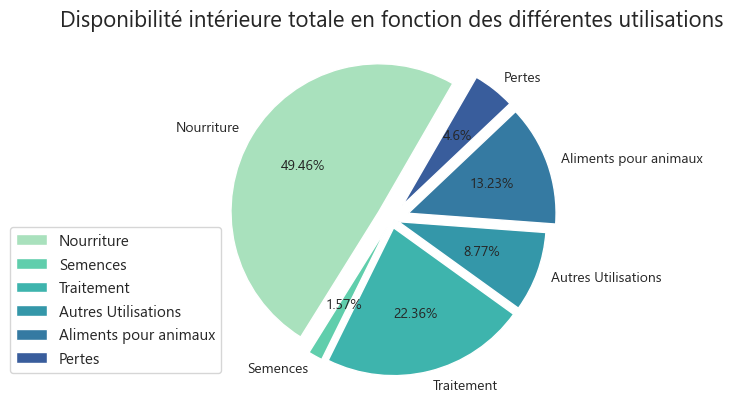

In [ ]:
# Pie de la disponibilité intérieure totale en fonction des différentes utilisations
colors = sns.color_palette("mako_r",9)

plt.title(
    "Disponibilité intérieure totale en fonction des différentes utilisations",
    fontsize=16,
    fontweight="bold"
)

plt.pie(
    x=[
        da_p["Nourriture"].sum(),
        da_p["Semences"].sum(),
        da_p["Traitement"].sum(),
        da_p["Autres Utilisations"].sum(),
        da_p["Aliments pour animaux"].sum(),
        da_p["Pertes"].sum(),
    ],
    labels=[
        "Nourriture",
        "Semences",
        "Traitement",
        "Autres Utilisations",
        "Aliments pour animaux",
        "Pertes",
    ],
    startangle=60,
    explode=[0.1, 0.06, 0.06, 0.05, 0.12, 0.12],
    autopct=lambda x: str(round(x, 2)) + "%",
    textprops={'fontsize': 10},
    colors=colors,
)
plt.legend(bbox_to_anchor=(0.06, 0.5))

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [ ]:
# Création d'une liste avec toutes les variables
variables = da_p.columns.to_list()

In [ ]:
# Détail des différents produits présents dans le DF
liste_pdt = da_p["Produit"].unique()
print(liste_pdt)

<StringArray>
[        'Abats Comestible',          'Agrumes, Autres',
    'Aliments pour enfants',                   'Ananas',
                  'Bananes',             'Beurre, Ghee',
                    'Bière',                      'Blé',
     'Boissons Alcooliques',                     'Café',
       'Coco (Incl Coprah)',                    'Crème',
         'Céréales, Autres',                   'Dattes',
       'Edulcorants Autres',            'Feve de Cacao',
           'Fruits, Autres',         'Graines de coton',
     'Graines de tournesol',   'Graisses Animales Crue',
  'Huil Plantes Oleif Autr',   'Huile Graines de Coton',
         'Huile d'Arachide',            'Huile d'Olive',
  'Huile de Colza&Moutarde',           'Huile de Palme',
            'Huile de Soja',          'Huile de Sésame',
       'Huile de Tournesol',       'Lait - Excl Beurre',
          'Légumes, Autres',      'Légumineuses Autres',
                     'Maïs',                     'Miel',
                 

In [ ]:
# Création d'un DF avec les informations uniquement pour les céréales
dispo_cereales = pd.DataFrame(
    da_p[
        da_p["Produit"].isin(
            [
                "Maïs",
                "Orge",
                "Seigle",
                "Sorgho",
                "Blé",
                "Céréales, Autres",                
                "Millet",
                "Riz (Eq Blanchi)",
                "Avoine",
            ]
        )
    ]
)
dispo_cereales.head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal
7,Afghanistan,Blé,vegetale,0.000000e+00,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,...,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-3.500000e+08,2017.0,36296113.0,4.968938e+10
12,Afghanistan,"Céréales, Autres",vegetale,0.000000e+00,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.000000e+00,2017.0,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,2.000000e+08,0.0,21.0,2.50,0.30,0.56,3.130000e+08,...,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.000000e+00,2017.0,36296113.0,7.622184e+08
34,Afghanistan,Millet,vegetale,0.000000e+00,0.0,3.0,0.40,0.02,0.08,1.300000e+07,...,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.000000e+00,2017.0,36296113.0,1.088883e+08
40,Afghanistan,Orge,vegetale,3.600000e+08,0.0,26.0,2.92,0.24,0.79,5.240000e+08,...,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.000000e+00,2017.0,36296113.0,9.436989e+08
47,Afghanistan,Riz (Eq Blanchi),vegetale,0.000000e+00,0.0,141.0,13.82,0.27,2.70,4.610000e+08,...,1.190000e+08,4.220000e+08,24000000.0,3.420000e+08,14000000.0,0.0,0.000000e+00,2017.0,36296113.0,5.117752e+09
67,Afrique du Sud,Avoine,vegetale,8.000000e+06,0.0,5.0,0.75,0.09,0.16,4.900000e+07,...,2.500000e+07,4.000000e+07,1000000.0,2.800000e+07,1000000.0,0.0,0.000000e+00,2017.0,57009756.0,2.850488e+08
72,Afrique du Sud,Blé,vegetale,3.700000e+07,0.0,492.0,60.13,2.09,15.40,3.316000e+09,...,1.490000e+09,3.174000e+09,74000000.0,1.870000e+09,31000000.0,0.0,4.500000e+08,2017.0,57009756.0,2.804880e+10
81,Afrique du Sud,"Céréales, Autres",vegetale,8.000000e+06,0.0,1.0,0.07,0.00,0.02,1.200000e+07,...,3.000000e+06,4.000000e+06,0.0,1.900000e+07,0.0,0.0,0.000000e+00,2017.0,57009756.0,5.700976e+07
111,Afrique du Sud,Maïs,vegetale,4.715000e+09,0.0,858.0,100.10,7.69,21.91,1.048000e+10,...,5.600000e+07,5.283000e+09,405000000.0,1.181100e+10,33000000.0,43000000.0,1.650000e+09,2017.0,57009756.0,4.891437e+10


In [ ]:
# Verification de l'absence de doublons
dispo_cereales.duplicated().sum()

np.int64(0)

In [ ]:
# Affichage de la proportion d'alimentation pour animaux en rapport avec les utilisations totales de céréales
cereales_total = dispo_cereales["Disponibilité intérieure"].sum()
cereales_animaux = dispo_cereales["Aliments pour animaux"].sum()
prop_cer_anim = cereales_animaux / cereales_total * 100
print(
    f"La quantité de céréales disponibles est de : {cereales_total:,.2f} kg".replace(
        ",", " "
    )
)
print(
    f"La quantité de céréales à destination des animaux est de : {cereales_animaux:,.2f} kg".replace(
        ",", " "
    )
)
print(
    f"La proportion de céréales à destination des animaux en rapport avec la totalité de céréales est de : {prop_cer_anim:,.2f} %".replace(
        ",", " "
    )
)

La quantité de céréales disponibles est de : 2 406 999 000 000.00 kg
La quantité de céréales à destination des animaux est de : 873 535 000 000.00 kg
La proportion de céréales à destination des animaux en rapport avec la totalité de céréales est de : 36.29 %


In [ ]:
# Affichage de la proportion d'alimentation animale --> humaine - nourriture ?
cereales_hum = dispo_cereales["Nourriture"].sum()
prop_cer_hum = cereales_hum / cereales_total * 100

print(
    f"La quantité de céréales à destination des humains est de : {cereales_hum:,.2f} kg".replace(
        ",", " "
    )
)
print(
    f"La proportion de céréales à destination des humains en rapport avec la totalité de céréales est de : {prop_cer_hum:,.2f} %".replace(
        ",", " "
    )
)

La quantité de céréales à destination des humains est de : 1 029 010 000 000.00 kg
La proportion de céréales à destination des humains en rapport avec la totalité de céréales est de : 42.75 %


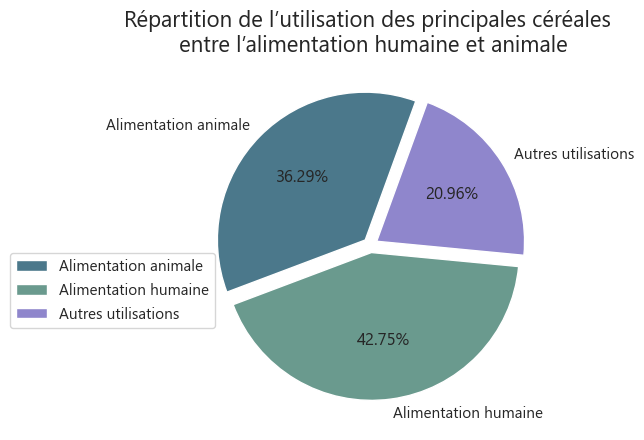

In [ ]:
# Graphique représentant la répartition de l’utilisation des principales céréales entre l’alimentation humaine et animale (en rapport avec les autres utilisations)

rocket_colors = sns.color_palette("crest",2)
plt.title(
    "Répartition de l’utilisation des principales céréales \n entre l’alimentation humaine et animale",
    fontsize=16,
    fontweight="bold"
)
plt.pie(
    [prop_cer_anim, prop_cer_hum, 100-(prop_cer_anim+prop_cer_hum)],
    explode=(0.05, 0.05, 0.05),
    labels=['Alimentation animale', 'Alimentation humaine', 'Autres utilisations'],
    autopct='%1.2f%%',
    startangle=70,
    colors=('#4b788b','#6a9a8e', "#8f86cc"),
)
plt.legend(bbox_to_anchor=(0.1,0.5))

In [ ]:
# DF de groupement par produit
df_repartition = dispo_cereales.groupby("Produit")[["Aliments pour animaux", "Nourriture", "Disponibilité intérieure"]].sum().reset_index()

# Répartition entre animaux et humains
df_repartition["Utilisation animale"] = (df_repartition["Aliments pour animaux"] / df_repartition["Disponibilité intérieure"]) * 100
df_repartition["Utilisation humaine"] = (df_repartition["Nourriture"] / df_repartition["Disponibilité intérieure"]) * 100

# Tri par disponibilité totale pour un graphique 
df_repartition = df_repartition.sort_values(by="Disponibilité intérieure", ascending=False)

print(df_repartition[["Produit", "Aliments pour animaux", "Nourriture", "Utilisation animale", "Utilisation humaine"]])

            Produit  Aliments pour animaux    Nourriture  Utilisation animale  \
3              Maïs           5.461160e+11  1.251840e+11            57.137118   
1               Blé           1.296680e+11  4.578240e+11            19.082911   
6  Riz (Eq Blanchi)           3.359400e+10  3.772860e+11             7.062667   
5              Orge           9.265800e+10  6.794000e+09            65.977399   
8            Sorgho           2.480800e+10  2.415300e+10            42.598348   
4            Millet           3.306000e+09  2.304000e+10            11.052790   
2  Céréales, Autres           1.903500e+10  5.324000e+09            69.255958   
0            Avoine           1.625100e+10  3.903000e+09            69.427949   
7            Seigle           8.099000e+09  5.502000e+09            48.886340   

   Utilisation humaine  
3            13.097314  
1            67.376799  
6            79.319088  
5             4.837688  
8            41.473634  
4            77.028518  
2            1

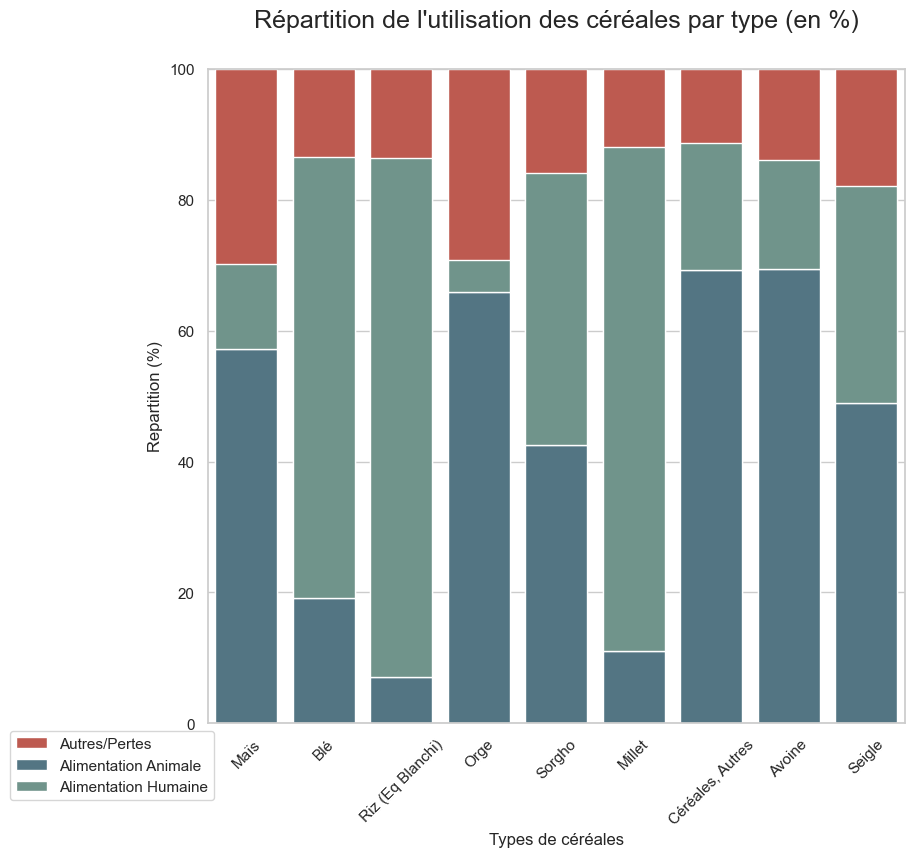

In [ ]:
# Graphique représentant la répartition de l'utilisation des céréales par type d'utilisation
sns.set_style("whitegrid") 
plt.figure(figsize=(9, 8.5))

bar1 = sns.barplot(x="Produit", y=[100]*len(df_repartition), data=df_repartition, color="#cf4b3e", label="Autres/Pertes")
bar2 = sns.barplot(x="Produit", y="Utilisation animale", data=df_repartition, color="#4b788b", label="Alimentation Animale")
bar3 = sns.barplot(x="Produit", y="Utilisation humaine", data=df_repartition, color="#6a9a8e", label="Alimentation Humaine", 
                   bottom=df_repartition["Utilisation animale"])

plt.title("Répartition de l'utilisation des céréales par type (en %)", fontsize=18, pad=30)
plt.ylabel("Repartition (%)")
plt.xlabel("Types de céréales")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(0.02,0))


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
# Création de la colonne proportion par pays
p_sn_2017["Proportion par pays"] = (
    round((p_sn_2017["Sous Nutrition"] / p_sn_2017["Population"]), 4) * 100
)

In [ ]:
# affichage après tri des 10 pires pays
p_sn_2017 = p_sn_2017.sort_values("Proportion par pays", ascending=False)
p_sn_2017.head(10)

,Zone,Année2017p,Population,Sous Nutrition,Proportion par pays
87,Haïti,2017,10982366.0,5300000.0,48.26
181,République populaire démocratique de Corée,2017,25429825.0,12000000.0,47.19
128,Madagascar,2017,25570512.0,10500000.0,41.06
122,Libéria,2017,4702226.0,1800000.0,38.28
119,Lesotho,2017,2091534.0,800000.0,38.25
216,Tchad,2017,15016753.0,5700000.0,37.96
186,Rwanda,2017,11980961.0,4200000.0,35.06
145,Mozambique,2017,28649018.0,9400000.0,32.81
219,Timor-Leste,2017,1243258.0,400000.0,32.17
0,Afghanistan,2017,36296113.0,10500000.0,28.93


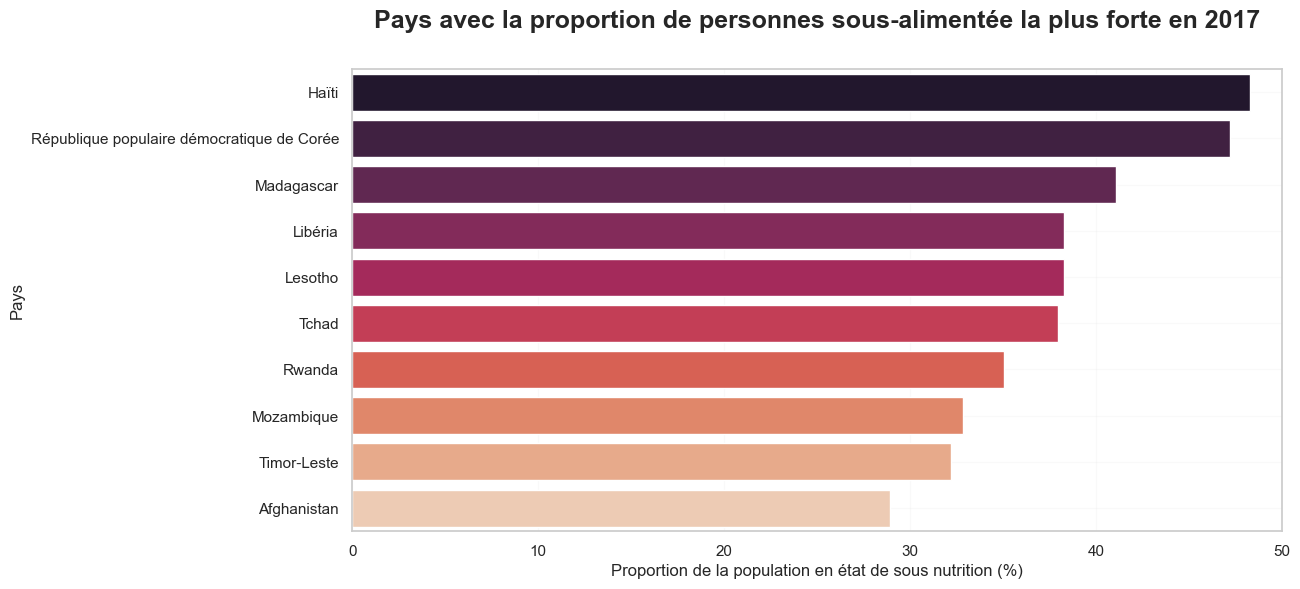

In [ ]:
#graphique des 10 pires pays en sous nutrition
plt.figure(figsize=(12, 6))

plt.title(
    'Pays avec la proportion de personnes sous-alimentée la plus forte en 2017',
    fontsize=18,
    fontweight="bold",
    pad=30,
)

sns.barplot(
    data=p_sn_2017.head(10),
    y='Zone',
    hue='Zone',
    x='Proportion par pays',
    palette='rocket',
    legend=False
)

plt.xlabel('Proportion de la population en état de sous nutrition (%)')
plt.ylabel("Pays")
plt.xlim(0, 50)
plt.grid(alpha=0.1)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [ ]:
# Aperçu du DF aide alimentaire
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


In [ ]:
# calcul du total de l'aide alimentaire par pays
aide_alim_totale = aide_alimentaire.groupby(["Zone"], as_index=False)["Valeur"].sum()
aide_alim_totale.head(10)

,Zone,Valeur
0,Afghanistan,185452000
1,Algérie,81114000
2,Angola,5014000
3,Bangladesh,348188000
4,Bhoutan,2666000
5,Bolivie (État plurinational de),6000
6,Burkina Faso,64812000
7,Burundi,77318000
8,Bénin,22224000
9,Cambodge,25780000


In [ ]:
# affichage après tri des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alim_totale = aide_alim_totale.sort_values("Valeur", ascending=False)
aide_alim_totale.head(10)

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


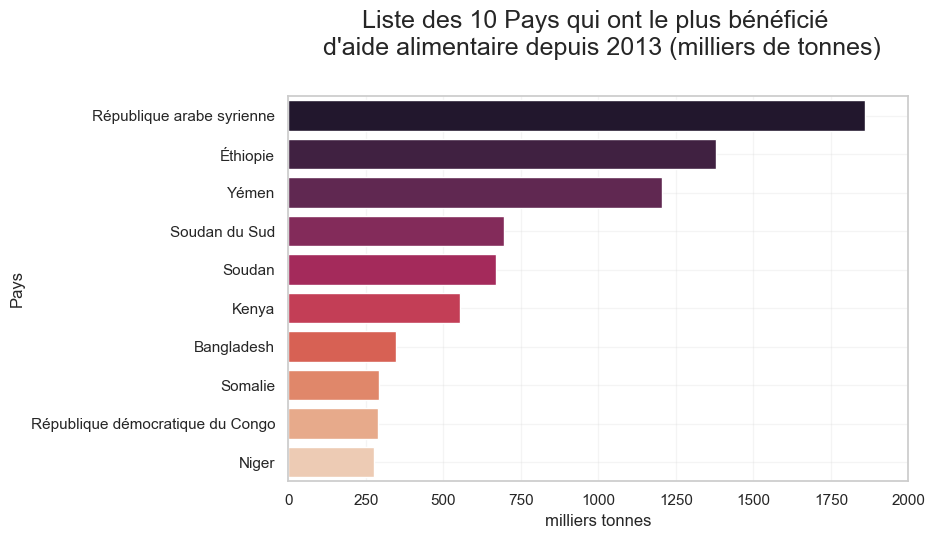

In [ ]:
# Graphique représentant les 10 Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013 

aide_alim_totale['Valeur_milliers_tonnes'] = (aide_alim_totale['Valeur'] / 1_000_000).round(0)
plt.figure(figsize=(8, 5))
plt.title(
    "Liste des 10 Pays qui ont le plus bénéficié \n d'aide alimentaire depuis 2013 (milliers de tonnes)",
    fontsize=18, pad=30
)

sns.barplot(
    data=aide_alim_totale.head(10), 
    y='Zone', 
    hue='Zone',
    x='Valeur_milliers_tonnes',  
    palette='rocket', 
    legend=False, 
)

plt.xlabel("milliers tonnes")
plt.ylabel("Pays")
plt.xlim(0, 2_000)  
plt.grid(alpha=0.2)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
# Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
# dataframe aide_alimentaire
# colonnes : Pays bénéficiaire,Année,Valeur
# sum(valeur) group by pays puis Année
aide_alimentaire["Année"] = aide_alimentaire["Année"].astype(int)
aide_alim_pays = aide_alimentaire.loc[
    aide_alimentaire["Année"].isin([2013, 2016]), ["Zone", "Année", "Valeur"]]
aide_alim_pays.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,682000
2,Afghanistan,2013,39224000
4,Afghanistan,2013,40504000
6,Afghanistan,2013,85000
7,Afghanistan,2013,11087000


In [ ]:
# Groupby sur pays bénéficiaire puis année
aide_alim_pays = aide_alim_pays.groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
aide_alim_pays.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Algérie,2013,35234000
2,Algérie,2016,9476000
3,Angola,2013,5000000
4,Bangladesh,2013,131018000


In [ ]:
# Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
cat_evolution = ["Zone", "Année", "Valeur"]
evolution_aide_alim = aide_alimentaire[cat_evolution]
evolution_aide_alim = evolution_aide_alim.groupby(["Zone", "Année"]).sum().reset_index()
evolution_aide_alim.head()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [ ]:
# Création d'une liste contenant les 5 pays qui ont le plus bénéficié de l'aide alimentaire  => Evolution la plus importante entre 2013 et 2016
top_augm = evolution_aide_alim.sort_values(by="Valeur", ascending=False)
top5 = top_augm["Zone"].unique().tolist()
top5 = top5[:5]
print(top5)

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [ ]:
# Création d'un DF ne contenant que le top 5
df_top5 = evolution_aide_alim.loc[evolution_aide_alim["Zone"].isin(top5)]
df_top5.head(35)

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


In [ ]:
# Vérification de l'absence de doublons
df_top5.duplicated().sum()

np.int64(0)

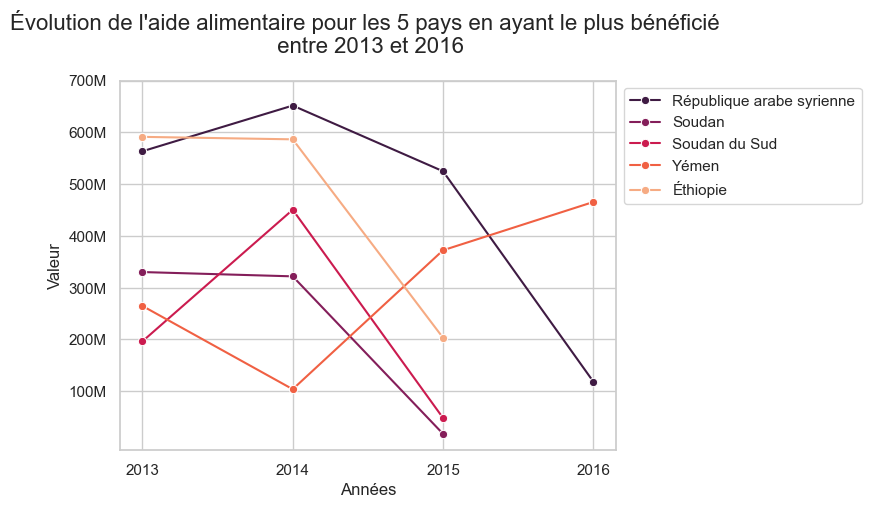

In [ ]:
# Graphique représentant l'évolution de l'aide alimentaire pour les 5 pays en ayant le plus bénéficié entre 2013 et 2016
sns.lineplot(data=df_top5, 
            x="Année", 
            y="Valeur", 
            hue="Zone", 
            marker="o", 
            palette="rocket", 
            )
plt.xticks([2013, 2014, 2015, 2016])

plt.yticks([100_000_000, 200_000_000, 300_000_000, 400_000_000, 
            500_000_000, 600_000_000, 700_000_000])
plt.title(
    "Évolution de l'aide alimentaire pour les 5 pays en ayant le plus bénéficié \n entre 2013 et 2016",
    fontsize=16,
    pad=20
)
plt.gca().set_yticklabels(['100M', '200M', '300M', '400M', '500M', '600M', '700M'])

plt.xlabel("Années")

plt.legend(bbox_to_anchor=(1, 1.0))


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
# Calcul de la disponibilité en kcal par personne par jour par pays
da_par_pays = dispo_alimentaire.groupby("Zone").sum()

In [ ]:
# Verification de l'absence de doublons
da_par_pays.duplicated().sum()

np.int64(0)

In [ ]:
# Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
da_par_pays.sort_values("Disponibilité alimentaire (Kcal/personne/jour)", inplace=True)
da_par_pays.head(10)

,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
Zone,,,,,,,,,,,,,,,,,
République centrafricaine,"Abats ComestibleAlcool, non ComestibleAliments...",animalevegetalevegetalevegetalevegetalevegetal...,1000000.0,2.700000e+07,1879.0,453.73,59.41,46.04,2.582000e+09,0.000000e+00,7.600000e+07,2.092000e+09,1.220000e+08,2.503000e+09,63000000.0,2.780000e+08,3.000000e+06
Zambie,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetalevegetal...,408000000.0,6.900000e+07,1924.0,350.12,42.05,55.22,1.004100e+10,6.750000e+08,3.800000e+08,5.088000e+09,2.420000e+08,1.052600e+10,76000000.0,4.178000e+09,-1.820000e+08
Madagascar,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,842000000.0,2.522000e+09,2056.0,425.07,24.49,46.69,1.521600e+10,2.360000e+08,9.240000e+08,9.741000e+09,9.660000e+08,1.416000e+10,375000000.0,8.440000e+08,3.750000e+08
Afghanistan,"Abats ComestibleAgrumes, AutresAliments pour e...",animalevegetalevegetalevegetalevegetaleanimale...,768000000.0,4.150000e+08,2087.0,351.41,33.50,58.26,1.351500e+10,2.780000e+08,2.988000e+09,1.073500e+10,1.135000e+09,1.117100e+10,395000000.0,6.300000e+07,-3.680000e+08
Haïti,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,481000000.0,1.150000e+08,2089.0,397.78,48.92,47.70,6.175000e+09,1.500000e+07,1.204000e+09,4.101000e+09,6.790000e+08,5.072000e+09,36000000.0,7.620000e+08,-7.700000e+07
République populaire démocratique de Corée,Abats ComestibleAnimaux Aquatiques AutreAvoine...,animaleanimalevegetaleanimalevegetalevegetalev...,816000000.0,6.950000e+08,2093.0,458.93,36.41,54.99,1.487600e+10,8.300000e+07,9.930000e+08,1.142500e+10,1.066000e+09,1.388300e+10,194000000.0,6.780000e+08,8.400000e+07
Tchad,"Abats ComestibleAlcool, non ComestibleAliments...",animalevegetalevegetaleanimalevegetalevegetale...,104000000.0,2.000000e+06,2109.0,319.45,47.10,62.75,5.304000e+09,0.000000e+00,2.900000e+08,4.097000e+09,4.590000e+08,5.153000e+09,101000000.0,5.420000e+08,-1.410000e+08
Zimbabwe,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetalevegetal...,131000000.0,2.300000e+07,2113.0,336.59,57.18,48.32,9.507000e+09,2.780000e+08,1.342000e+09,4.762000e+09,1.880000e+08,7.914000e+09,76000000.0,4.330000e+09,5.310000e+08
Ouganda,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,348000000.0,6.800000e+07,2126.0,535.58,46.57,52.64,2.662400e+10,1.218000e+09,1.257000e+09,2.012100e+10,9.910000e+08,2.632100e+10,154000000.0,4.982000e+09,2.690000e+08


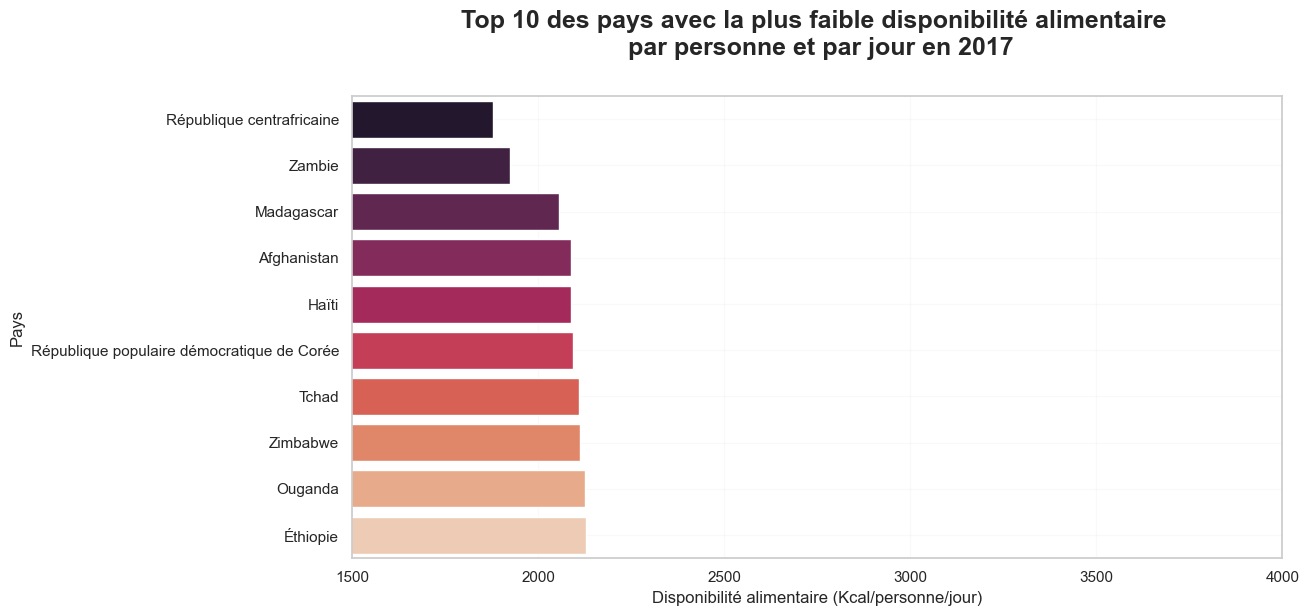

In [ ]:
# graphique affichant des 10 pays qui ont le moins de dispo alimentaire par personne
classement=da_par_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)',
                            ascending=True).head(10)

plt.figure(figsize=(12, 6))                     
plt.title(
    "Top 10 des pays avec la plus faible disponibilité alimentaire \n par personne et par jour en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)   
sns.barplot(
    data=classement,
    y='Zone',
    hue='Zone',
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    palette='rocket',
    legend=False
)
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel("Pays")
plt.xlim(1500, 4000)
plt.grid(alpha=0.1)


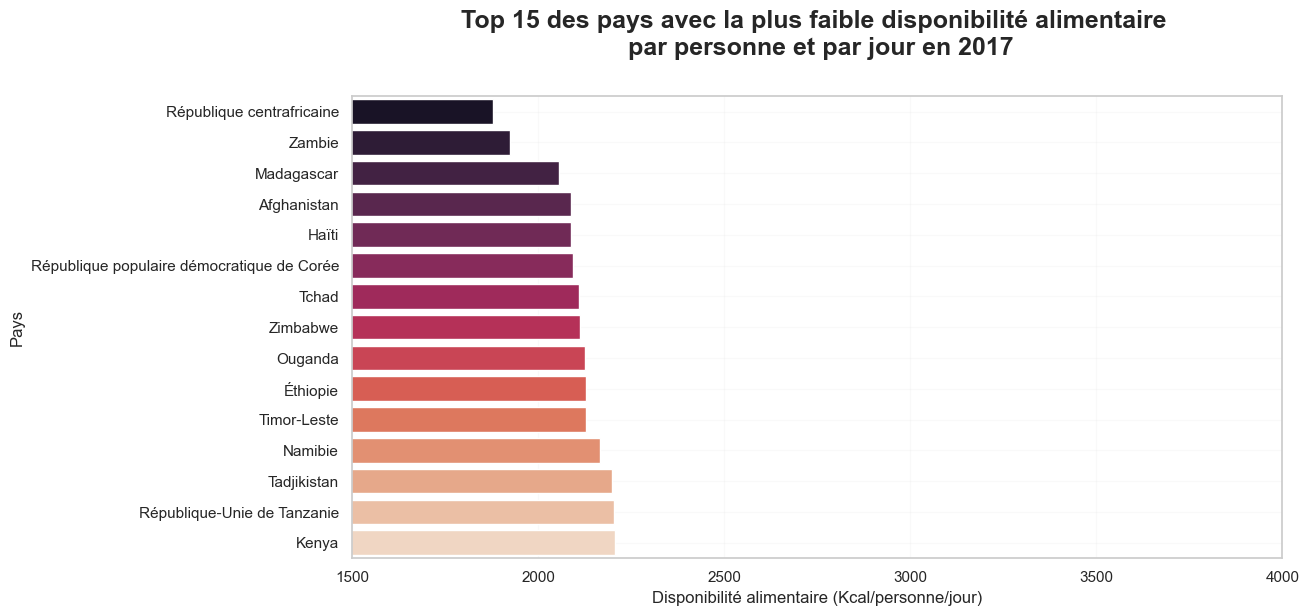

In [ ]:
# graphique affichant des 15 pays qui ont le moins de dispo alimentaire par personne
classement=da_par_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)',
                            ascending=True).head(15)                            

plt.figure(figsize=(12, 6))                     
plt.title(
    "Top 15 des pays avec la plus faible disponibilité alimentaire \n par personne et par jour en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)   
sns.barplot(
    data=classement,
    y='Zone',
    hue='Zone',
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    palette='rocket',
    legend=False
)
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel("Pays")
plt.xlim(1500, 4000)
plt.grid(alpha=0.1)

    

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [ ]:
# Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
da_par_pays.sort_values("Disponibilité alimentaire (Kcal/personne/jour)", ascending=False, inplace=True)
da_par_pays.head(10)

,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
Zone,,,,,,,,,,,,,,,,,
Autriche,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,3.412000e+09,1.001000e+09,3770.0,1069.20,170.44,106.20,1.930800e+10,6.733000e+09,8.463000e+09,9.085000e+09,4.590000e+08,1.812900e+10,1.730000e+08,5.178000e+09,-5.560000e+08
Belgique,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,5.533000e+09,3.226000e+09,3737.0,1002.09,161.95,99.37,2.935800e+10,3.034500e+10,3.527600e+10,1.113400e+10,5.640000e+08,2.449600e+10,1.530000e+08,8.960000e+09,-6.400000e+07
Turquie,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,1.775000e+10,3.006000e+09,3708.0,968.15,119.64,108.12,1.313770e+11,1.459300e+10,1.213600e+10,7.255100e+10,1.203600e+10,1.374320e+11,2.553000e+09,2.356000e+10,-3.599000e+09
États-Unis d'Amérique,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,1.484320e+11,1.546990e+11,3682.0,1002.39,161.37,109.42,7.779920e+11,1.635240e+11,8.188700e+10,3.208890e+11,7.162000e+09,8.946680e+11,1.040300e+10,1.410100e+11,-3.503200e+10
Israël,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,2.525000e+09,8.010000e+08,3610.0,922.14,151.39,128.00,1.126700e+10,1.648000e+09,5.883000e+09,7.132000e+09,2.200000e+08,6.906000e+09,7.100000e+07,5.640000e+08,1.280000e+08
Irlande,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,3.758000e+09,1.120000e+09,3602.0,1150.15,125.69,109.91,1.073800e+10,6.828000e+09,6.254000e+09,5.320000e+09,2.360000e+08,1.150100e+10,8.900000e+07,3.990000e+08,-1.920000e+08
Italie,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,1.614400e+10,3.228000e+09,3578.0,993.20,154.69,108.49,9.740500e+10,2.364300e+10,3.869200e+10,6.058400e+10,1.861000e+09,8.085500e+10,7.360000e+08,1.487000e+10,1.496000e+09
Luxembourg,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,1.470000e+08,1.100000e+07,3540.0,1150.66,141.49,113.64,8.020000e+08,8.210000e+08,1.076000e+09,6.070000e+08,1.100000e+07,5.930000e+08,9.000000e+06,2.400000e+07,-4.100000e+07
Égypte,"Abats ComestibleAgrumes, AutresAlcool, non Com...",animalevegetalevegetalevegetalevegetaleanimale...,1.508400e+10,2.262000e+09,3518.0,803.79,63.09,103.22,1.151330e+11,5.014000e+09,2.410000e+10,6.595700e+10,7.608000e+09,9.584800e+10,1.365000e+09,2.292400e+10,1.990000e+08


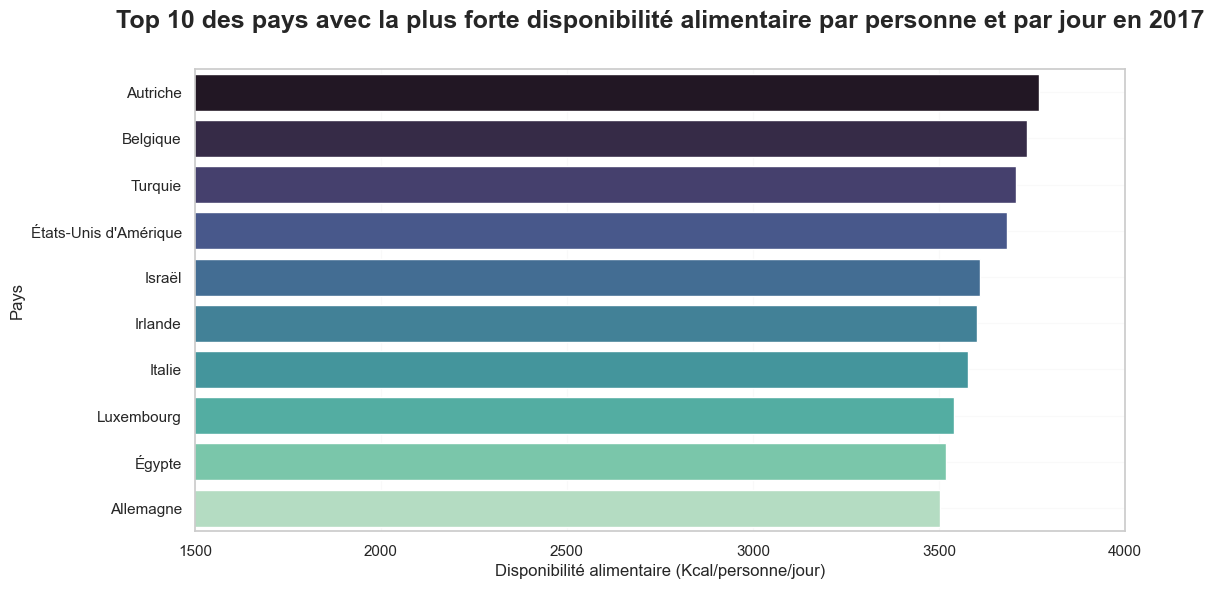

In [ ]:
# graphique affichant les 10 pays qui ont le plus de dispo alimentaire par personne
plt.figure(figsize=(12, 6))                     
plt.title(
    "Top 10 des pays avec la plus forte disponibilité alimentaire par personne et par jour en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)   
sns.barplot(
    data=da_par_pays.head(10).reset_index(),
    y='Zone',
    hue='Zone',
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    palette='mako',
    legend=False
)
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel("Pays")
plt.xlim(1500, 4000)
plt.grid(alpha=0.1)

    

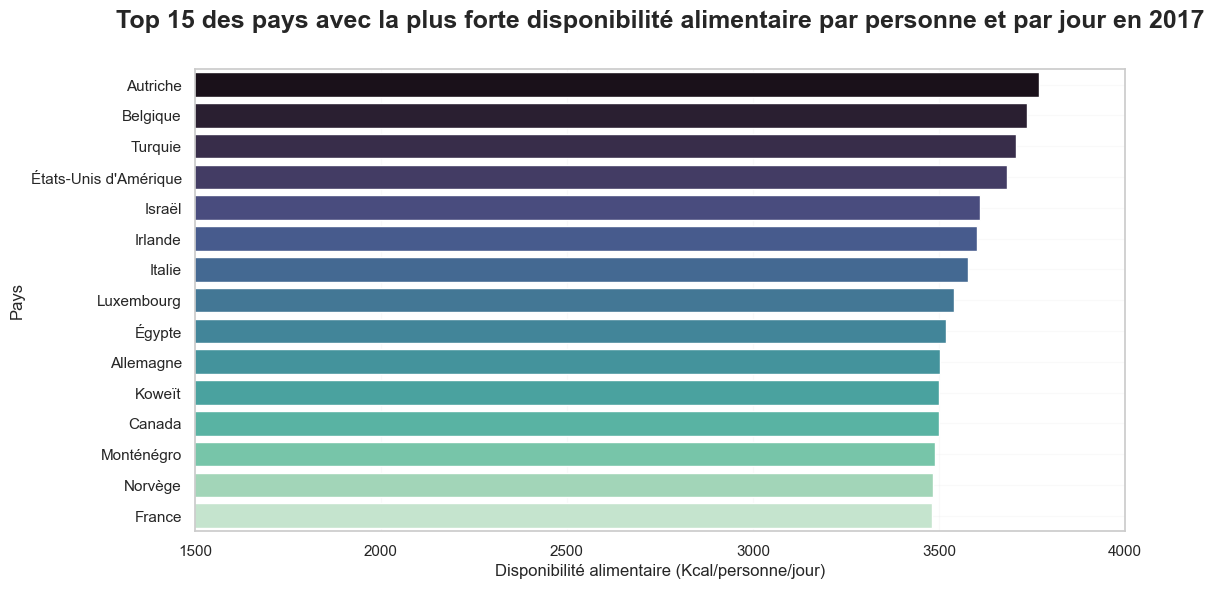

In [ ]:
# graphique affichant des 15 pays qui ont le plus de dispo alimentaire par personne
plt.figure(figsize=(12, 6))                     
plt.title(
    "Top 15 des pays avec la plus forte disponibilité alimentaire par personne et par jour en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)   
sns.barplot(
    data=da_par_pays.head(15).reset_index(),
    y='Zone',
    hue='Zone',
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    palette='mako',
    legend=False
)
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel("Pays")
plt.xlim(1500, 4000)
plt.grid(alpha=0.1)

    

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
# création d'un dataframe avec uniquement la Thaïlande
da_p_thailande = da_p.loc[da_p["Zone"] == "Thaïlande"]
p_sn_thailande = p_sn_2017.loc[p_sn_2017["Zone"] == "Thaïlande"]
thailande = pd.merge(da_p_thailande, p_sn_thailande, on="Zone")

In [ ]:
# Verification de l'absence de doublons
thailande.duplicated().sum()

np.int64(0)

In [ ]:
# Aperçu du DF
display(thailande.head())

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Semences,Traitement,Variation de stock,Année,Population_x,Dispo_kcal,Année2017p,Population_y,Sous Nutrition,Proportion par pays
0,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,207629430.0,2017,69209810.0,6200000.0,8.96
1,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000000.0,...,0.0,2000000.0,0.0,2017.0,69209810.0,0.0,2017,69209810.0,6200000.0,8.96
2,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000000.0,0.0,0.00,0.00,0.00,358000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,0.0,2017,69209810.0,6200000.0,8.96
3,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,138419620.0,2017,69209810.0,6200000.0,8.96
4,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000000.0,...,0.0,0.0,13000000.0,2017.0,69209810.0,692098100.0,2017,69209810.0,6200000.0,8.96


In [ ]:
# Calcul de la sous nutrition en Thaïlande
thailande_sn = thailande["Sous Nutrition"].iloc[0]
print(f"La quantité de personnes en état de sous-nutrition en Thaïlande est de : {thailande_sn:,.0f}".replace(",", " "))

La quantité de personnes en état de sous-nutrition en Thaïlande est de : 6 200 000


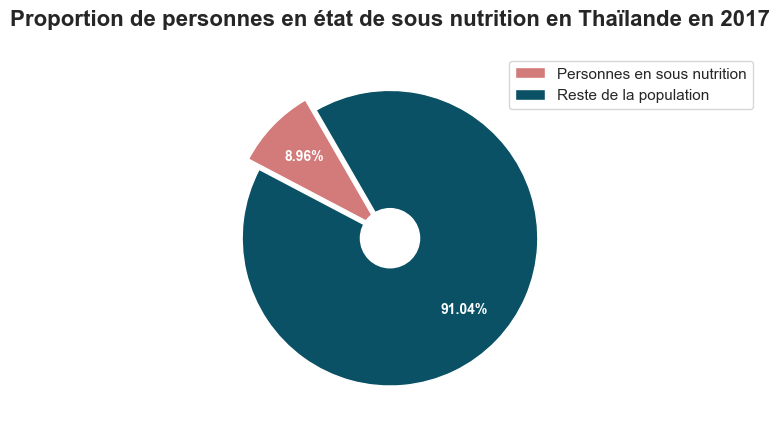

In [ ]:
# graphique représentant la part de personnes en état de sous-nutrition pour la Thaïlande
plt.title(
    'Proportion de personnes en état de sous nutrition en Thaïlande en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [thailande_sn, thailande["Population_y"].iloc[0] - thailande_sn],
    labels=[f'{thailande_sn:,.0f} personnes'.replace(',',' '), f'{thailande["Population_y"].iloc[0] - thailande_sn:,.0f} personnes'.replace(',',' ')],
    startangle=120,
    explode=[0.1, 0],  
    autopct=lambda x: str(round(x, 2)) + "%",
    colors = ["#D37A7A","#0A5166"] ,
    pctdistance = 0.7, 
    textprops={'fontsize': 10, 'fontweight':'bold', 'color': 'white'}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Personnes en sous nutrition', 'Reste de la population'],     bbox_to_anchor=(0.8,1))


In [ ]:
# On calcule la proportion exportée en fonction de la Production (GLOBAL)
thailande_export = round(((thailande["Exportations - Quantité"].sum() / thailande["Production"].sum()) * 100), 2,)

print("La Thaïlande exporte {} % de sa production totale.".format(thailande_export))

La Thaïlande exporte 24.99 % de sa production totale.


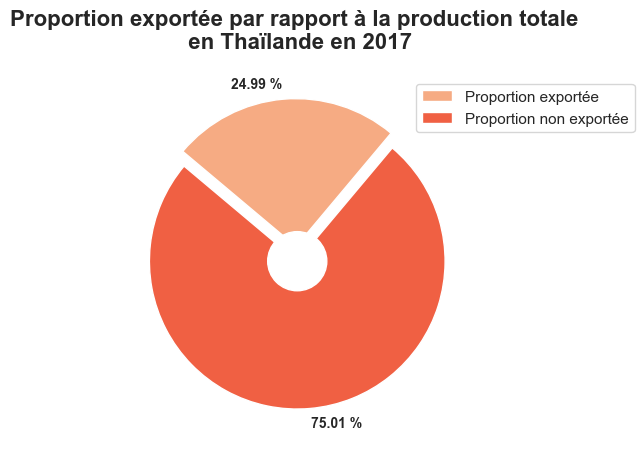

In [ ]:
# graphique représentant la part exportée par rapport à la production totale pour la Thaïlande
colors= sns.color_palette("rocket_r", 5)
plt.title(  
    'Proportion exportée par rapport à la production totale \n en Thaïlande en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [thailande_export, 100 - thailande_export],
    labels=[f'{thailande_export:.2f} %', f'{100 - thailande_export:.2f} %'],
    startangle=50,
    explode=[0.1, 0],
    pctdistance = 0.7, 
    colors=colors,
    textprops={'fontsize': 10, 'fontweight':'bold'}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Proportion exportée', 'Proportion non exportée'], bbox_to_anchor=(0.8,1))   


In [ ]:
# Filtre sur le Manioc en Thaïlande
thai_manioc = thailande[thailande["Produit"] == "Manioc"].iloc[0]

In [ ]:
display(thai_manioc.head(10))

Zone                                                                Thaïlande
Produit                                                                Manioc
Origine                                                              vegetale
Aliments pour animaux                                            1800000000.0
Autres Utilisations                                              2081000000.0
Disponibilité alimentaire (Kcal/personne/jour)                           40.0
Disponibilité alimentaire en quantité (kg/personne/an)                   13.0
Disponibilité de matière grasse en quantité (g/personne/jour)            0.05
Disponibilité de protéines en quantité (g/personne/jour)                 0.14
Disponibilité intérieure                                         6264000000.0
Name: 50, dtype: object

In [ ]:
#  Proportion de la production exportée par la Thaïlande
thai_manioc_exp_pourc = round(((thai_manioc["Exportations - Quantité"] / thai_manioc["Production"]) * 100), 2)

print(f"La Thaïlande exporte {thai_manioc_exp_pourc} % de sa production de manioc.")

La Thaïlande exporte 83.41 % de sa production de manioc.


In [ ]:
# Calcul de la quantité de Manioc en Kcal
thai_manioc_kcal=thai_manioc["Dispo_kcal"].sum()
thai_manioc_kcal=thai_manioc_kcal/besoin_kcal_j

print(f"La Thaïlande dispose de {thai_manioc_kcal:,.0f} Kcal de Manioc.".replace(",", " "))

La Thaïlande dispose de 1 107 357 Kcal de Manioc.


In [ ]:
# Calcul de la quantité de Manioc exportée
thai_manioc_exp = (thai_manioc["Exportations - Quantité"])

print(f"La Thaïlande exporte {thai_manioc_exp:,.0f} tonnes de manioc.".replace(
        ",", " "
    ).format(thai_manioc_exp))

La Thaïlande exporte 25 214 000 000 tonnes de manioc.


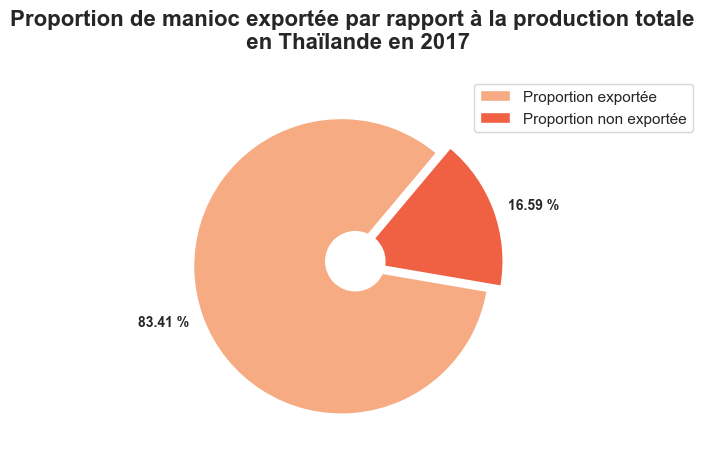

In [ ]:
# graphique représentant la part de manioc exportée par rapport à la production totale pour la Thaïlande
colors= sns.color_palette("rocket_r", 5)
plt.title(  
    'Proportion de manioc exportée par rapport à la production totale \n en Thaïlande en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [thai_manioc_exp_pourc, 100 - thai_manioc_exp_pourc],
    labels=[f'{thai_manioc_exp_pourc:.2f} %', f'{100 - thai_manioc_exp_pourc:.2f} %'],
    startangle=50,
    explode=[0.1, 0],
    pctdistance = 0.7, 
    colors=colors,
    textprops={'fontsize': 10, 'fontweight':'bold'}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Proportion exportée', 'Proportion non exportée'], bbox_to_anchor=(0.8,1))   


In [ ]:
# ------------------------------------------------------------------------ ANALYSE COMPLEMENTAIRE  ------------------------------------------------------------------------

# Calcul de la disponibilité alimentaire en kcal par personne par jour pour la Thaïlande
da_p_thailande["Dispo_kcal"] = (
    da_p_thailande["Disponibilité alimentaire (Kcal/personne/jour)"]
    * da_p_thailande["Population"]
)
dispo_kcal_tot_thai = da_p_thailande["Dispo_kcal"].sum()
p_nourrie_thai = dispo_kcal_tot_thai / besoin_kcal_j
print(f"Le nombre de personnes pouvant être nourries en Thaïlande est de : {p_nourrie_thai :,.0f} personnes".replace(",", " "))

Le nombre de personnes pouvant être nourries en Thaïlande est de : 77 099 728 personnes


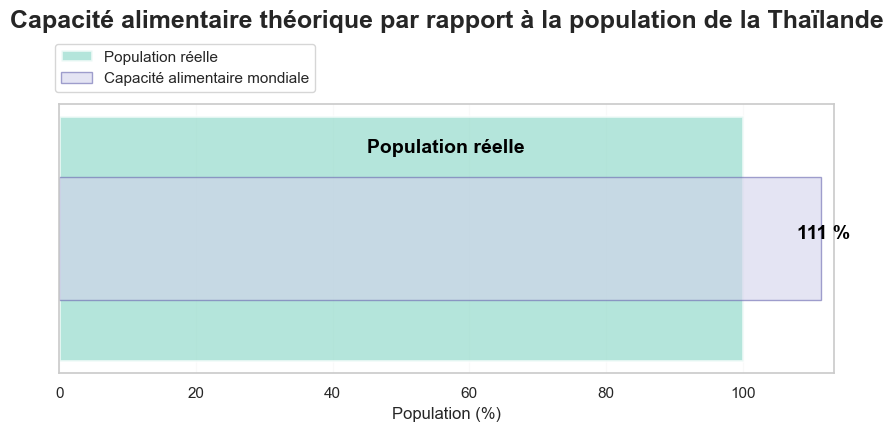

In [ ]:
# Graphique représentant la capacité alimentaire théorique par rapport à la population de la Thaïlande
proportion_nourrie_thai = round((p_nourrie_thai / thailande["Population_y"].iloc[0]) * 100,2)
population_100 = 100   

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_title('Capacité alimentaire théorique par rapport à la population de la Thaïlande', 
    fontsize=18, 
    fontweight='bold', 
    pad=55
    )

bars1 = ax.barh(0, 100,           
                height=0.20,
                color="#95DBCC",
                edgecolor='white',
                linewidth=2,
                alpha=0.7,
                label='Population réelle',
                )   
bars2 = ax.barh(0, proportion_nourrie_thai,
                height=0.1, 
                color="#D3D2EB",
                edgecolor="#6866AF",   
                alpha=0.6,
                label='Capacité alimentaire mondiale')
ax.text(
    45, 0.07,
    'Population réelle',
    fontweight='bold',
    fontsize=14,
    color='black'
    )
ax.text(
    108, 0,
    f'{proportion_nourrie_thai:.0f} %',
    fontweight='bold',
    fontsize=14,
    color='black'
    )
ax.set_xlabel(
    'Population (%)',
    fontsize=12
    )
ax.set_xlim(
    0,
    proportion_nourrie_thai +2
    )   
ax.set_yticks([])
plt.legend(bbox_to_anchor=(0.34,1.25))
plt.grid(alpha=0.1)


In [ ]:
display(thailande.info())

<class 'pandas.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 25 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           95 non-null     str    
 1   Produit                                                        95 non-null     str    
 2   Origine                                                        95 non-null     str    
 3   Aliments pour animaux                                          95 non-null     float64
 4   Autres Utilisations                                            95 non-null     float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 95 non-null     float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         95 non-null     float64
 7   Disponibilité de matière grasse en quantité (g/personne/jour)  95 non-null 

None

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [ ]:
# ------------------------------------------------------------------------ Etude plus globale du Manioc  ------------------------------------------------------------------------

# Import - classement
da_manioc=da_p.loc[da_p["Produit"] == "Manioc"]
da_manioc.sort_values('Importations - Quantité', ascending=False).head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal
3323,"Chine, continentale",Manioc,vegetale,2.286800e+10,7.940000e+09,6.0,1.91,0.01,0.05,3.359000e+10,...,2.904600e+10,2.645000e+09,1.380000e+08,4.585000e+09,0.0,0.000000e+00,0.0,2017.0,1.421022e+09,8.526131e+09
11769,République de Corée,Manioc,vegetale,0.000000e+00,1.230000e+08,0.0,0.11,0.00,0.00,1.933000e+09,...,1.933000e+09,5.000000e+06,0.000000e+00,0.000000e+00,0.0,1.804000e+09,0.0,2017.0,5.109642e+07,0.000000e+00
3228,"Chine, Taiwan Province de",Manioc,vegetale,1.000000e+06,1.317000e+09,0.0,0.05,0.00,0.00,1.320000e+09,...,1.324000e+09,1.000000e+06,0.000000e+00,1.500000e+07,0.0,0.000000e+00,63000000.0,2017.0,2.367455e+07,0.000000e+00
13809,Thaïlande,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.00,0.05,0.14,6.264000e+09,...,1.250000e+09,8.710000e+08,1.511000e+09,3.022800e+10,0.0,0.000000e+00,0.0,2017.0,6.920981e+07,2.768392e+09
6334,Indonésie,Manioc,vegetale,4.800000e+08,8.894000e+09,132.0,46.97,0.30,0.70,2.421900e+10,...,1.102000e+09,1.173500e+10,3.110000e+09,2.393700e+10,0.0,0.000000e+00,0.0,2017.0,2.646510e+08,3.493393e+10
8378,Malaisie,Manioc,vegetale,3.000000e+06,8.360000e+08,6.0,2.04,0.02,0.04,9.030000e+08,...,8.440000e+08,6.100000e+07,3.000000e+06,6.300000e+07,0.0,0.000000e+00,0.0,2017.0,3.110465e+07,1.866279e+08
7073,Japon,Manioc,vegetale,0.000000e+00,0.000000e+00,0.0,0.08,0.00,0.00,6.370000e+08,...,6.370000e+08,1.100000e+07,0.000000e+00,0.000000e+00,0.0,6.260000e+08,0.0,2017.0,1.275027e+08,0.000000e+00
15390,États-Unis d'Amérique,Manioc,vegetale,2.880000e+08,2.450000e+08,0.0,0.14,0.00,0.00,5.790000e+08,...,5.880000e+08,4.600000e+07,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,2017.0,3.250848e+08,0.000000e+00
10940,Philippines,Manioc,vegetale,1.420000e+08,2.010000e+08,64.0,23.27,0.19,0.44,2.632000e+09,...,2.760000e+08,2.289000e+09,0.000000e+00,2.361000e+09,0.0,0.000000e+00,0.0,2017.0,1.051729e+08,6.731067e+09
1303,Bangladesh,Manioc,vegetale,0.000000e+00,1.240000e+08,0.0,0.15,0.00,0.00,1.470000e+08,...,1.470000e+08,2.300000e+07,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,2017.0,1.596854e+08,0.000000e+00


In [ ]:
# Verification de l'absence de doublons
da_manioc.duplicated().sum()

np.int64(0)

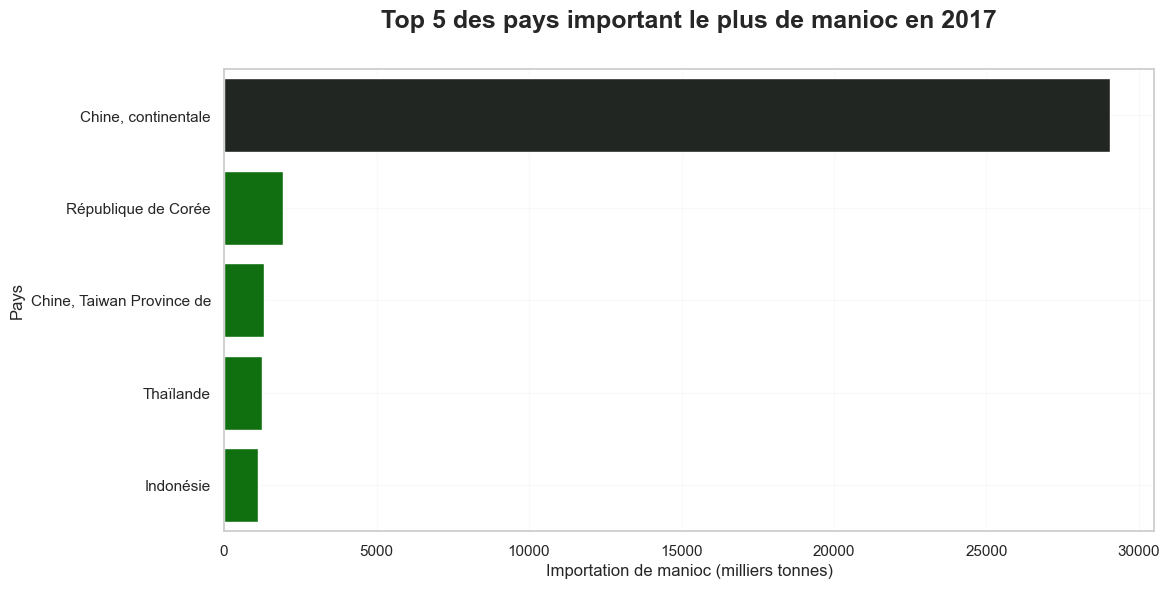

In [ ]:
# graphique représentant les 5 pays important le plus de manioc

da_manioc_import = da_p.loc[da_p['Produit'] == 'Manioc']
da_manioc_import=da_manioc_import.sort_values('Importations - Quantité', ascending=False).head(5)

da_manioc_import['Import_kt'] = (da_manioc_import['Importations - Quantité'] / 1_000_000).round(0)

plt.figure(figsize=(12, 6))
plt.title(
    "Top 5 des pays important le plus de manioc en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)

sns.barplot(
    data=da_manioc_import.reset_index(),
    y='Zone',
    x='Import_kt',
    hue='Importations - Quantité',
    palette='dark:green_r',
    legend=False
)

plt.xlabel('Importation de manioc (milliers tonnes)')
plt.ylabel("Pays")
plt.grid(alpha=0.1)

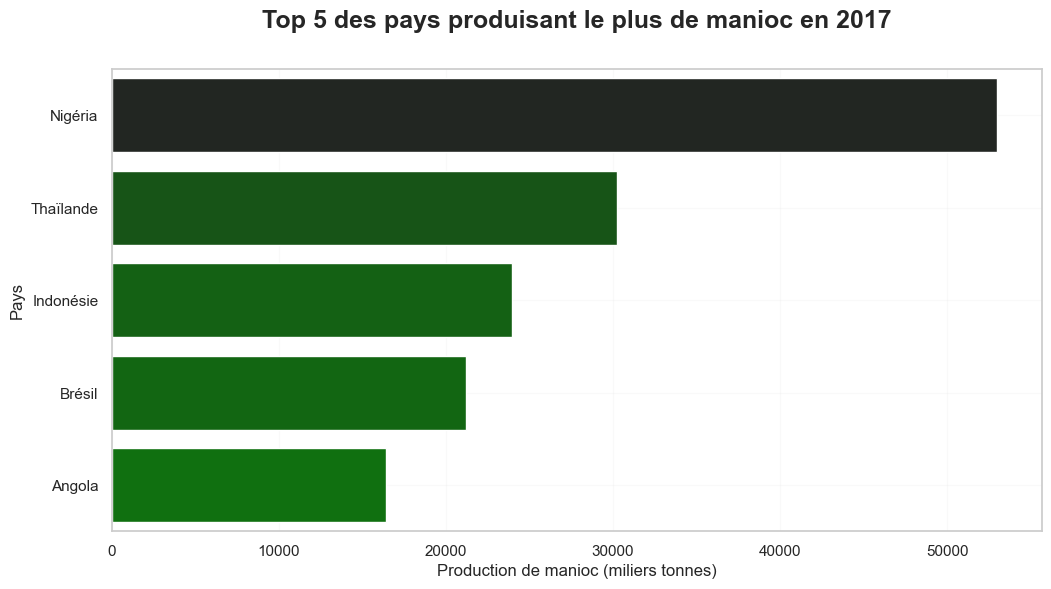

In [ ]:
# graphique représentant les 5 pays produisant le plus de manioc
da_manioc_prod = da_p.loc[da_p['Produit'] == 'Manioc']
da_manioc_prod=da_manioc_prod.sort_values('Production', ascending=False).head(5)

da_manioc_prod['Prod_kt'] = (da_manioc_prod['Production'] / 1_000_000).round(0)

plt.figure(figsize=(12, 6))
plt.title(
    "Top 5 des pays produisant le plus de manioc en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)

sns.barplot(
    data=da_manioc_prod.reset_index(),
    y='Zone',
    x='Prod_kt',
    hue='Production',
    palette='dark:green_r',
    legend=False
)

plt.xlabel('Production de manioc (miliers tonnes)')
plt.ylabel("Pays")
plt.grid(alpha=0.1)


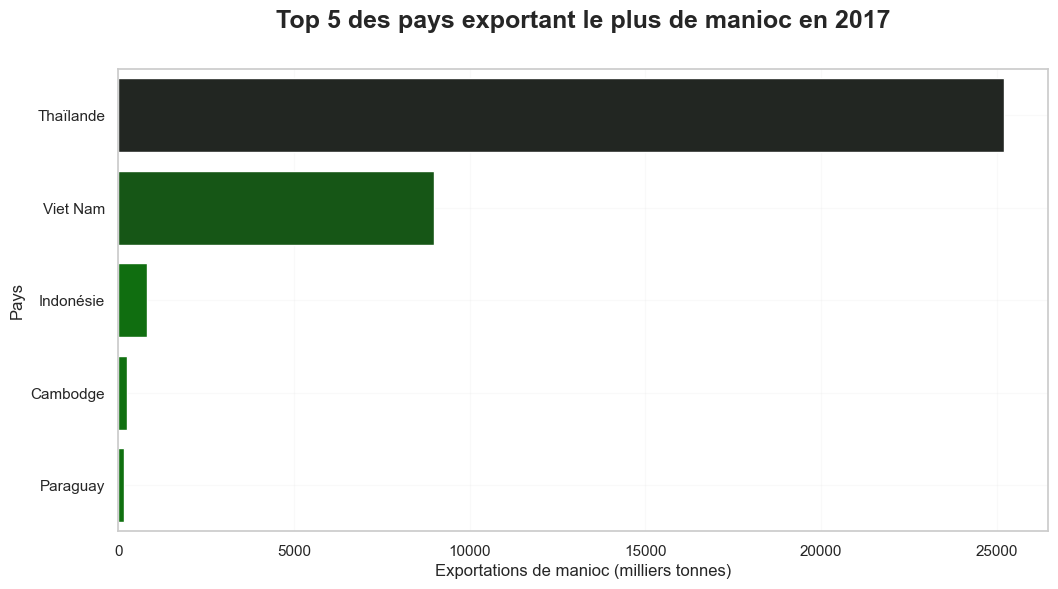

In [ ]:
# graphique représentant les 5 pays exportant le plus de manioc
da_manioc_export = da_p.loc[da_p['Produit'] == 'Manioc']
da_manioc_export=da_manioc_export.sort_values('Exportations - Quantité', ascending=False).head(5)

da_manioc_export['export_kt'] = (da_manioc_export['Exportations - Quantité'] / 1_000_000).round(0)

plt.figure(figsize=(12, 6))
plt.title(
    "Top 5 des pays exportant le plus de manioc en 2017",
    fontsize=18,
    fontweight="bold",
    pad=30,
)

sns.barplot(
    data=da_manioc_export.reset_index(),
    y='Zone',
    x='export_kt',
    hue='Exportations - Quantité',
    palette='dark:green_r',
    legend=False
)

plt.xlabel('Exportations de manioc (milliers tonnes)')
plt.ylabel("Pays")
plt.grid(alpha=0.1)


In [ ]:
# création d'un dataframe avec uniquement le manioc
da_manioc = da_p.loc[da_p["Produit"] == "Manioc"]
total_manioc=da_manioc['Disponibilité intérieure'].sum()

print(f"La quantité mondiale de Manioc s'élève à {total_manioc:,.0f} kg de manioc.".replace(
        ",", " "))

La quantité mondiale de Manioc s'élève à 256 664 000 000 kg de manioc.


In [ ]:
# ------------------------------------------------------------------------ Etude globale sur les céréales  ------------------------------------------------------------------------

# Affichage du DF avec les informations uniquement pour les céréales
dispo_cereales.head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal
7,Afghanistan,Blé,vegetale,0.000000e+00,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,...,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-3.500000e+08,2017.0,36296113.0,4.968938e+10
12,Afghanistan,"Céréales, Autres",vegetale,0.000000e+00,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.000000e+00,2017.0,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,2.000000e+08,0.0,21.0,2.50,0.30,0.56,3.130000e+08,...,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.000000e+00,2017.0,36296113.0,7.622184e+08
34,Afghanistan,Millet,vegetale,0.000000e+00,0.0,3.0,0.40,0.02,0.08,1.300000e+07,...,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.000000e+00,2017.0,36296113.0,1.088883e+08
40,Afghanistan,Orge,vegetale,3.600000e+08,0.0,26.0,2.92,0.24,0.79,5.240000e+08,...,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.000000e+00,2017.0,36296113.0,9.436989e+08
47,Afghanistan,Riz (Eq Blanchi),vegetale,0.000000e+00,0.0,141.0,13.82,0.27,2.70,4.610000e+08,...,1.190000e+08,4.220000e+08,24000000.0,3.420000e+08,14000000.0,0.0,0.000000e+00,2017.0,36296113.0,5.117752e+09
67,Afrique du Sud,Avoine,vegetale,8.000000e+06,0.0,5.0,0.75,0.09,0.16,4.900000e+07,...,2.500000e+07,4.000000e+07,1000000.0,2.800000e+07,1000000.0,0.0,0.000000e+00,2017.0,57009756.0,2.850488e+08
72,Afrique du Sud,Blé,vegetale,3.700000e+07,0.0,492.0,60.13,2.09,15.40,3.316000e+09,...,1.490000e+09,3.174000e+09,74000000.0,1.870000e+09,31000000.0,0.0,4.500000e+08,2017.0,57009756.0,2.804880e+10
81,Afrique du Sud,"Céréales, Autres",vegetale,8.000000e+06,0.0,1.0,0.07,0.00,0.02,1.200000e+07,...,3.000000e+06,4.000000e+06,0.0,1.900000e+07,0.0,0.0,0.000000e+00,2017.0,57009756.0,5.700976e+07
111,Afrique du Sud,Maïs,vegetale,4.715000e+09,0.0,858.0,100.10,7.69,21.91,1.048000e+10,...,5.600000e+07,5.283000e+09,405000000.0,1.181100e+10,33000000.0,43000000.0,1.650000e+09,2017.0,57009756.0,4.891437e+10


In [ ]:
# Classement des 5 plus gros producteurs de chaque céréale
liste_cereales = dispo_cereales["Produit"].unique()

for cereale in liste_cereales:
    print(f"Top 5 Producteurs : {cereale}") 
    liste_pays_cereales = dispo_cereales[dispo_cereales["Produit"] == cereale]
    print(liste_pays_cereales.sort_values(by="Production", ascending=False)[["Zone", "Production"]].head(5))
    

Top 5 Producteurs : Blé
                        Zone    Production
3284     Chine, continentale  1.219260e+11
6199                    Inde  9.351000e+10
15352  États-Unis d'Amérique  5.796700e+10
4946    Fédération de Russie  5.209100e+10
4851                  France  3.861400e+10
Top 5 Producteurs : Céréales, Autres
                       Zone    Production
11007               Pologne  7.404000e+09
15454              Éthiopie  4.672000e+09
361               Allemagne  2.690000e+09
4860                 France  2.559000e+09
4955   Fédération de Russie  1.451000e+09
Top 5 Producteurs : Maïs
                        Zone    Production
15391  États-Unis d'Amérique  3.536990e+11
3324     Chine, continentale  2.184890e+11
2130                  Brésil  8.053800e+10
750                Argentine  3.211900e+10
14386                Ukraine  3.095000e+10
Top 5 Producteurs : Millet
                     Zone    Production
6241                 Inde  1.091000e+10
9833              Nigéria  5.000000e+09

In [ ]:
# Classement des 5 plus gros importateurs de chaque céréale
for cereale in liste_cereales:
    print(f"Top 5 Importateurs {cereale} :")
    liste_pays_cereales = dispo_cereales[dispo_cereales["Produit"] == cereale]
    print(liste_pays_cereales.sort_values(by="Importations - Quantité", ascending=False)[["Zone", "Importations - Quantité"]].head(5))

Top 5 Importateurs Blé :
            Zone  Importations - Quantité
15071     Égypte             1.033100e+10
2090      Brésil             7.630000e+09
6296   Indonésie             7.074000e+09
7034       Japon             6.520000e+09
259      Algérie             6.343000e+09
Top 5 Importateurs Céréales, Autres :


                        Zone  Importations - Quantité
361                Allemagne              298000000.0
15361  États-Unis d'Amérique              281000000.0
9080                 Mexique              235000000.0
10817               Pays-Bas              204000000.0
4394                 Espagne              147000000.0
Top 5 Importateurs Maïs :
                      Zone  Importations - Quantité
7074                 Japon             1.440300e+10
11770  République de Corée             8.755000e+09
9109               Mexique             7.261000e+09
15109               Égypte             5.852000e+09
4424               Espagne             5.698000e+09
Top 5 Importateurs Millet :
                              Zone  Importations - Quantité
14833                        Yémen               23000000.0
1493                      Belgique               21000000.0
15393        États-Unis d'Amérique               21000000.0
393                      Allemagne               19000000.0
12172  Rép

In [ ]:
# Classement des 5 plus gros exportateurs de chaque céréale
for cereale in liste_cereales:
    print(f"Top 5 Exportateurs {cereale} :")
    liste_pays_cereales = dispo_cereales[dispo_cereales["Produit"] == cereale]
    print(liste_pays_cereales.sort_values(by="Exportations - Quantité", ascending=False)[["Zone", "Exportations - Quantité"]].head(5))

Top 5 Exportateurs Blé :
                        Zone  Exportations - Quantité
15352  États-Unis d'Amérique             3.469100e+10
4851                  France             2.150200e+10
2815                  Canada             2.070400e+10
895                Australie             1.817100e+10
4946    Fédération de Russie             1.424300e+10
Top 5 Exportateurs Céréales, Autres :
            Zone  Exportations - Quantité
2824      Canada              509000000.0
361    Allemagne              271000000.0
13779  Thaïlande              222000000.0
7981    Lituanie              206000000.0
11007    Pologne              205000000.0
Top 5 Exportateurs Maïs :
                        Zone  Exportations - Quantité
2130                  Brésil             2.678000e+10
15391  États-Unis d'Amérique             2.465500e+10
750                Argentine             2.024100e+10
14386                Ukraine             1.681600e+10
4890                  France             6.514000e+09
Top 5 Expor

In [ ]:
# Classement des 5 plus gros exportateurs de chaque céréale
for cereale in liste_cereales:
    print(f"Top 5 Exportateurs {cereale} :")
    liste_pays_cereales = dispo_cereales[dispo_cereales["Produit"] == cereale]
    print(liste_pays_cereales.sort_values(by="Exportations - Quantité", ascending=False)[["Zone", "Exportations - Quantité"]].head(5))

NameError: name 'liste_cereales' is not defined

In [ ]:
liste_cereales = dispo_cereales["Produit"].unique()

for cereale in liste_cereales:
    df_cereale = dispo_cereales[dispo_cereales["Produit"] == cereale].copy()

    top5_producteurs = (
        df_cereale
        .nlargest(5, "Production")[["Zone", "Production"]]
        .assign(Production_kt=lambda d: d["Production"] / 1_000)
    )

    top5_exportateurs = (
        df_cereale
        .nlargest(5, "Exportations - Quantité")[["Zone", "Exportations - Quantité"]]
        .assign(Exportation_kt=lambda d: d["Exportations - Quantité"] / 1_000)
    )

    top5_importateurs = (
        df_cereale
        .nlargest(5, "Importations - Quantité")[["Zone", "Importations - Quantité"]]
        .assign(Importation_kt=lambda d: d["Importations - Quantité"] / 1_000)
    )



NameError: name 'dispo_cereales' is not defined

In [ ]:
 plot_top5_cereale(
        cereale,
        top5_producteurs,
        top5_exportateurs,
        top5_importateurs
    )


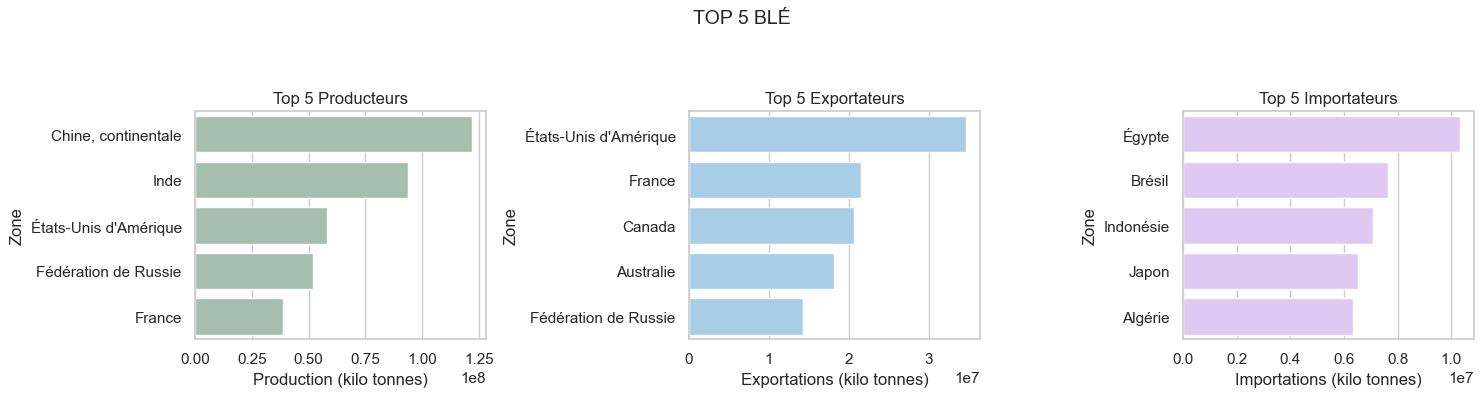

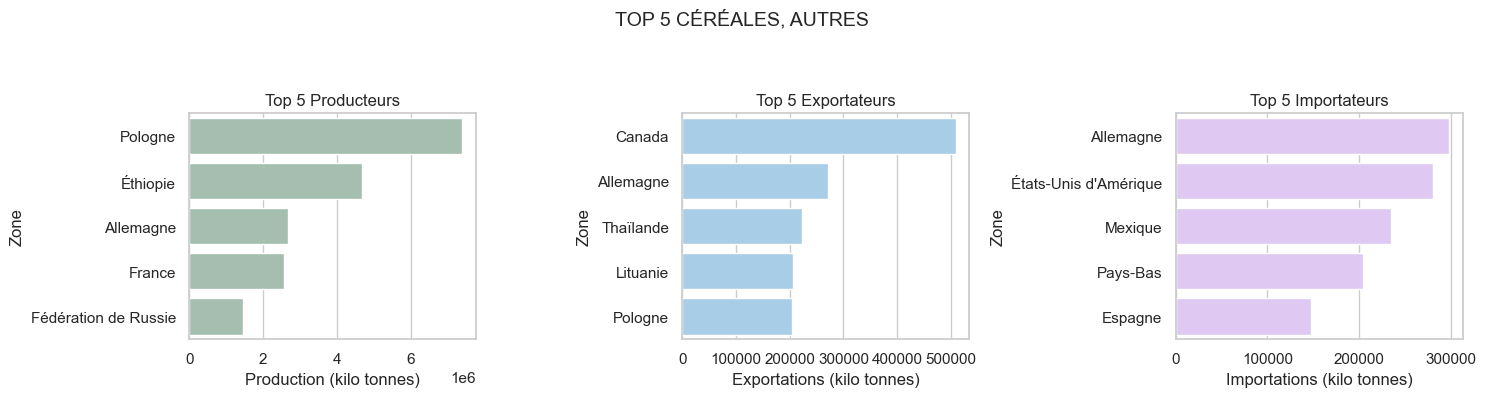

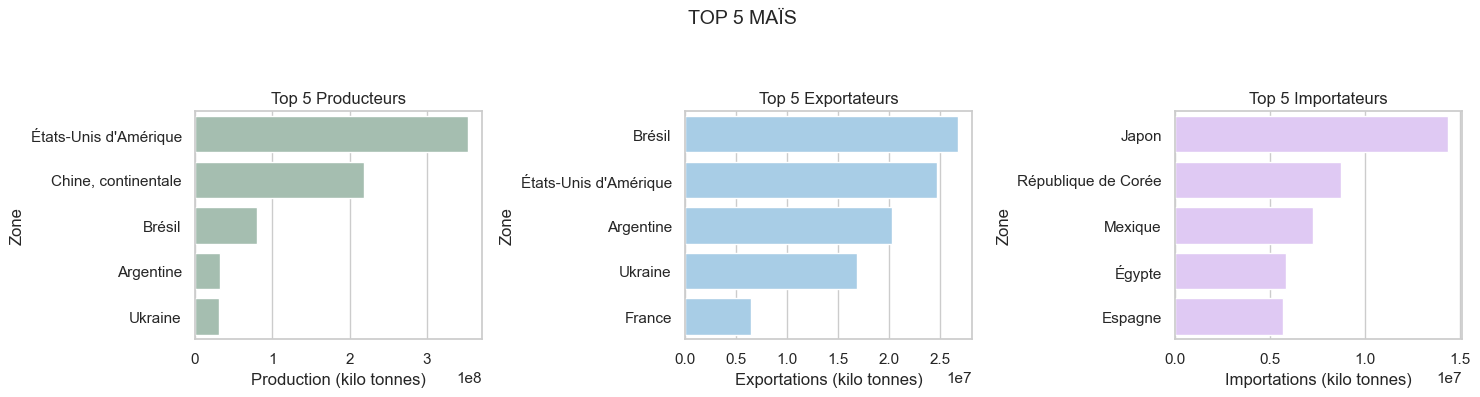

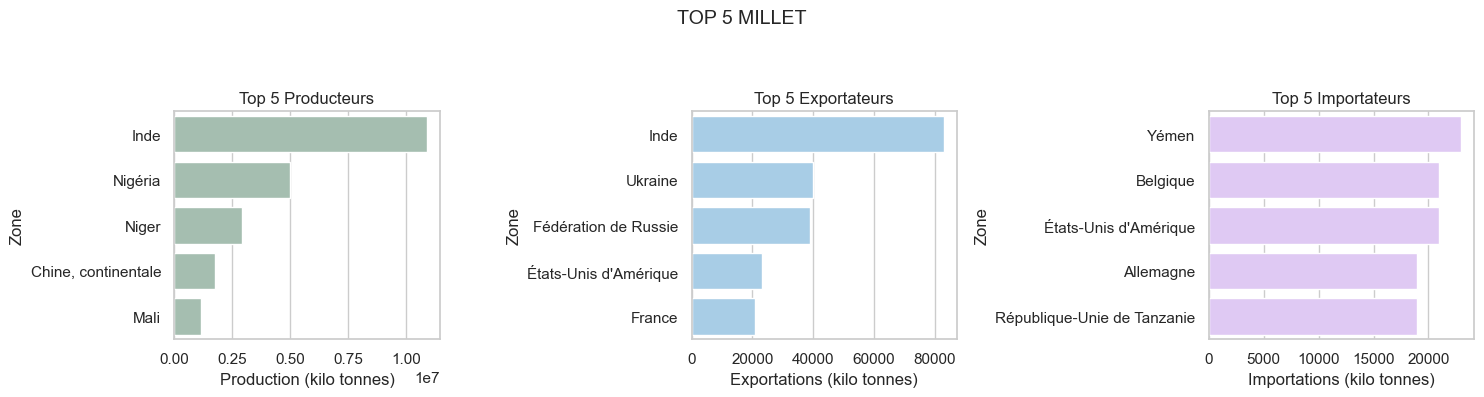

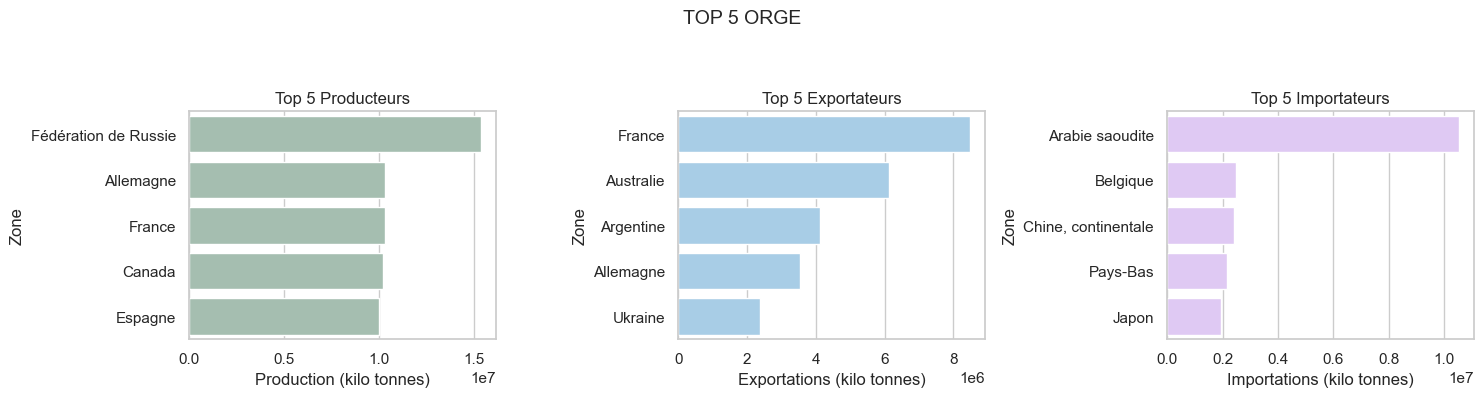

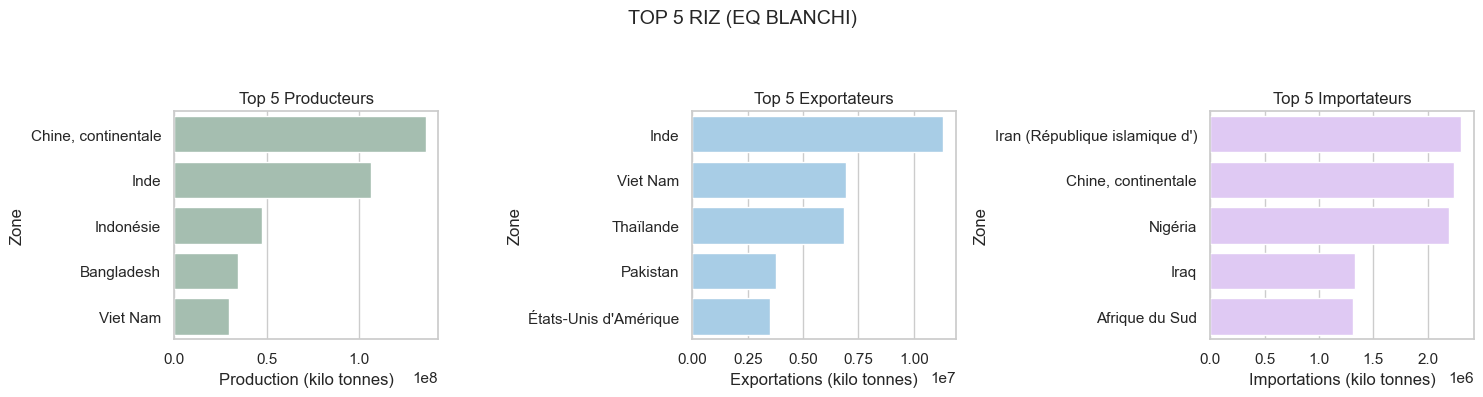

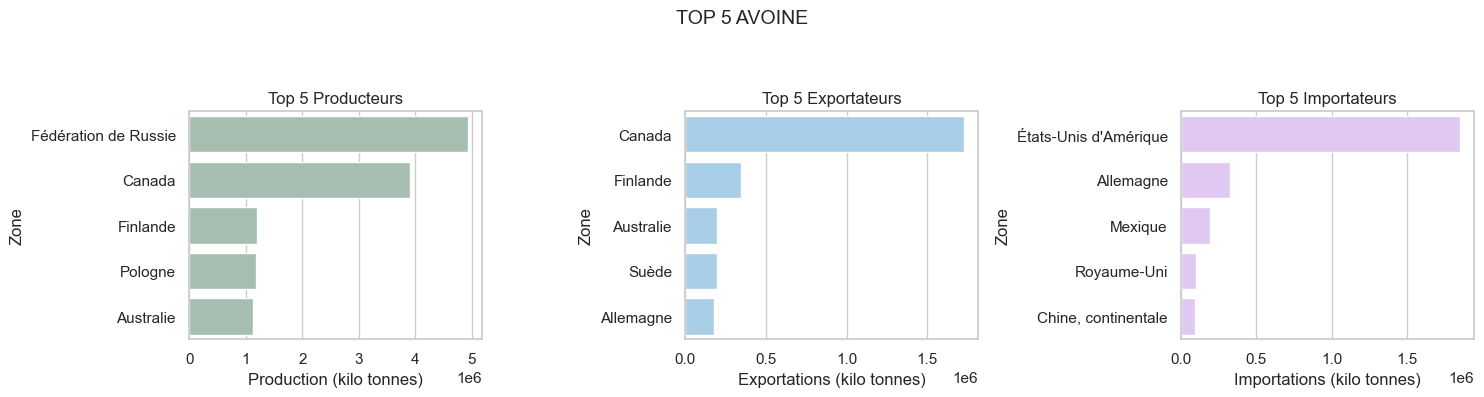

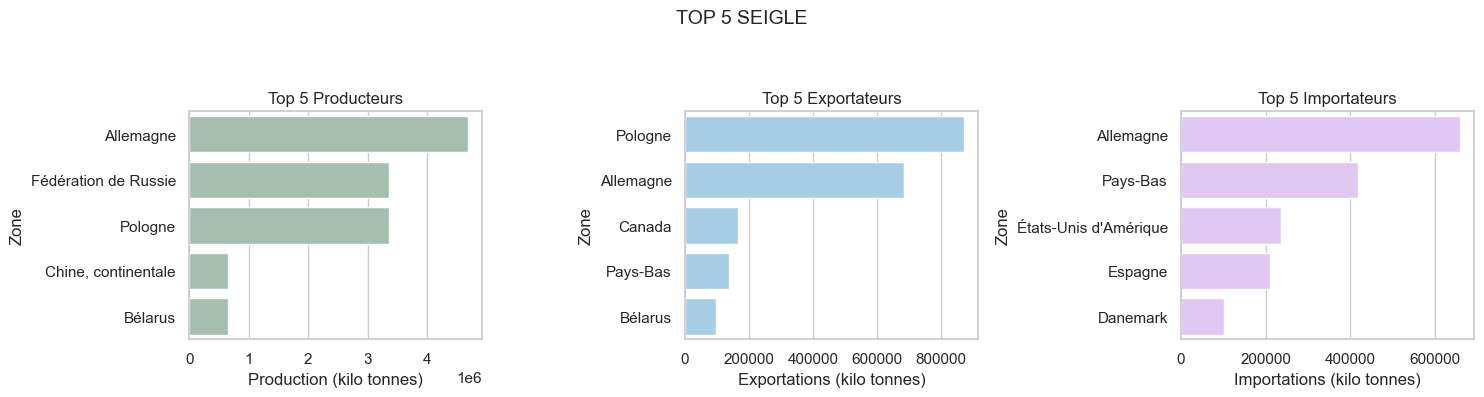

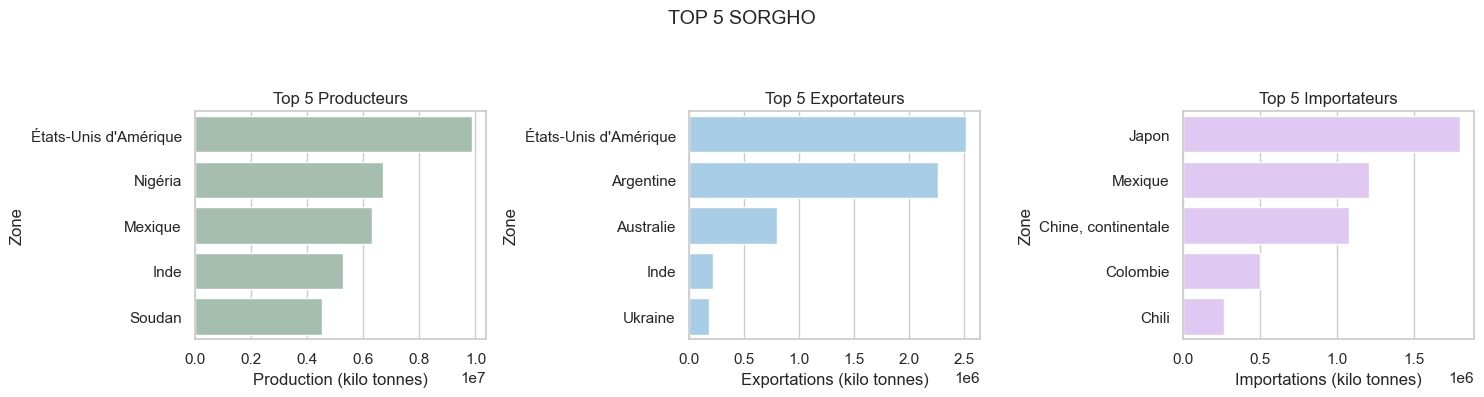

In [ ]:
liste_cereales = dispo_cereales["Produit"].unique()

for cereale in liste_cereales:
    # 1. Filtrer sur la céréale en cours
    df_cereale = dispo_cereales[dispo_cereales["Produit"] == cereale].copy()
    
    # 2. Recalculer les top 5 pour CETTE céréale
    top5_producteurs = (
        df_cereale
        .nlargest(5, "Production")[["Zone", "Production"]]
        .assign(Production_kt=lambda d: d["Production"] / 1_000)
    )

    top5_exportateurs = (
        df_cereale
        .nlargest(5, "Exportations - Quantité")[["Zone", "Exportations - Quantité"]]
        .assign(Exportation_kt=lambda d: d["Exportations - Quantité"] / 1_000)
    )

    top5_importateurs = (
        df_cereale
        .nlargest(5, "Importations - Quantité")[["Zone", "Importations - Quantité"]]
        .assign(Importation_kt=lambda d: d["Importations - Quantité"] / 1_000)
    )

    # 3. Création des graphiques
    figure, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    figure.suptitle(f'TOP 5 {cereale}'.upper(), fontsize=14, y=1.02)
    
    sns.barplot(data=top5_producteurs, y="Zone", hue='Zone',
                x="Production_kt", ax=ax1,
                palette=['#a1c2af']*5, linewidth=1)
    ax1.set_title('Top 5 Producteurs', fontsize=12)
    ax1.set_xlabel('Production (kilo tonnes)')

    sns.barplot(data=top5_exportateurs, y="Zone", hue='Zone',
                x="Exportation_kt", ax=ax2,
                palette=['#9ecff0']*5, linewidth=1)
    ax2.set_title('Top 5 Exportateurs', fontsize=12)
    ax2.set_xlabel('Exportations (kilo tonnes)')

    sns.barplot(data=top5_importateurs, y="Zone", hue='Zone',
                x="Importation_kt", ax=ax3,
                palette=['#dfc2fa']*5, linewidth=1)
    ax3.set_title('Top 5 Importateurs', fontsize=12)
    ax3.set_xlabel('Importations (kilo tonnes)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


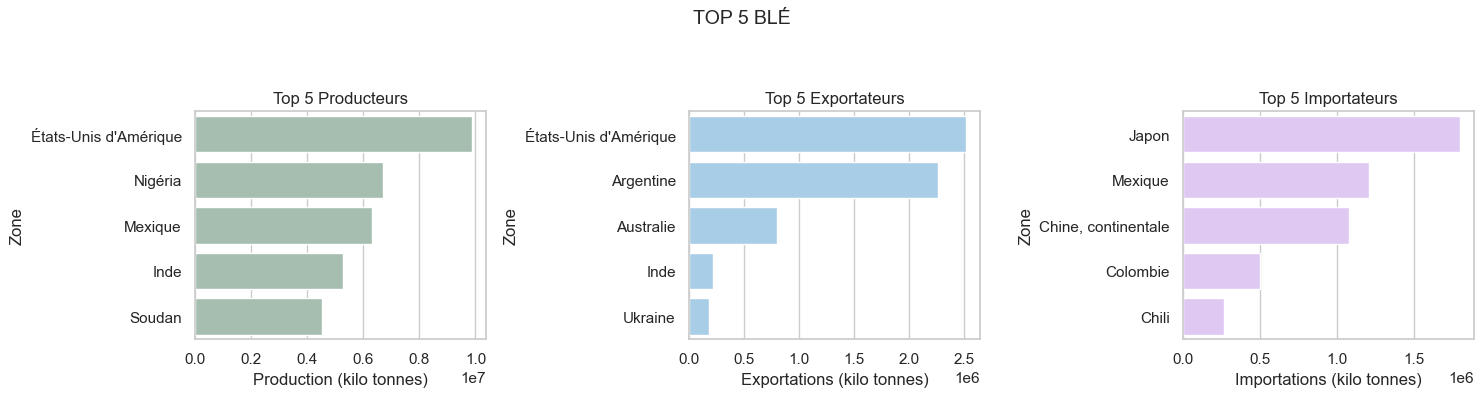

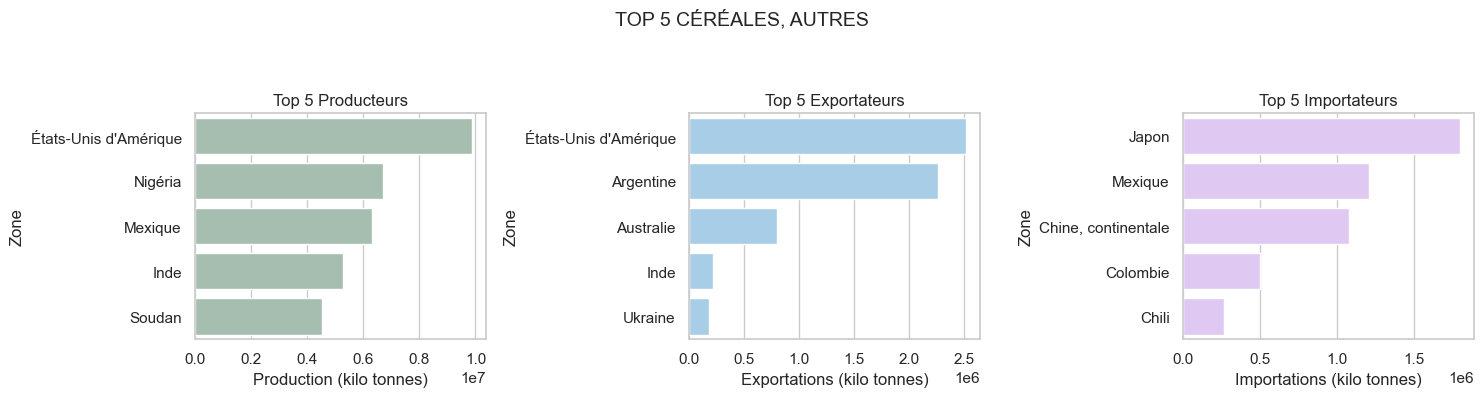

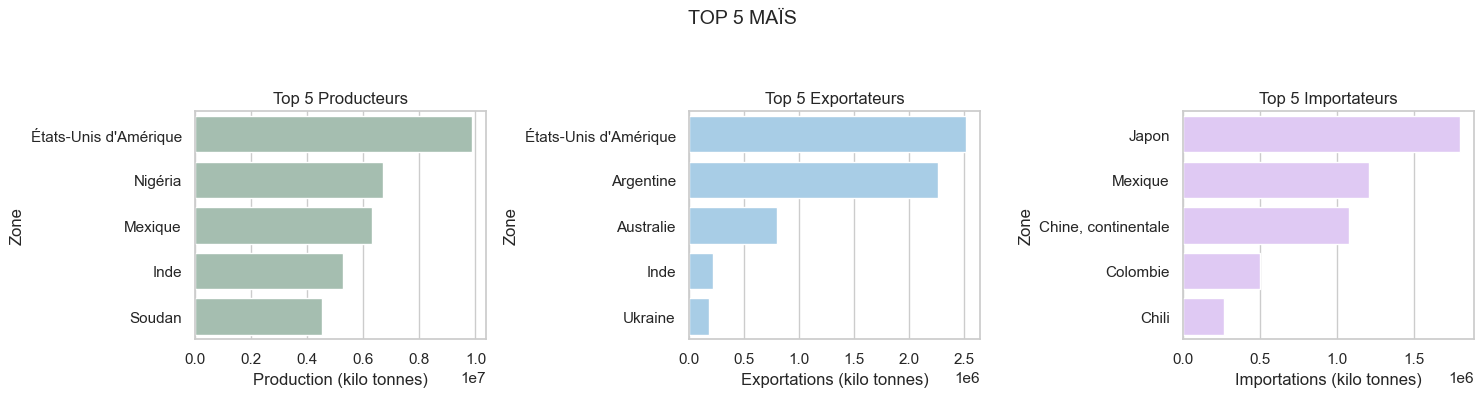

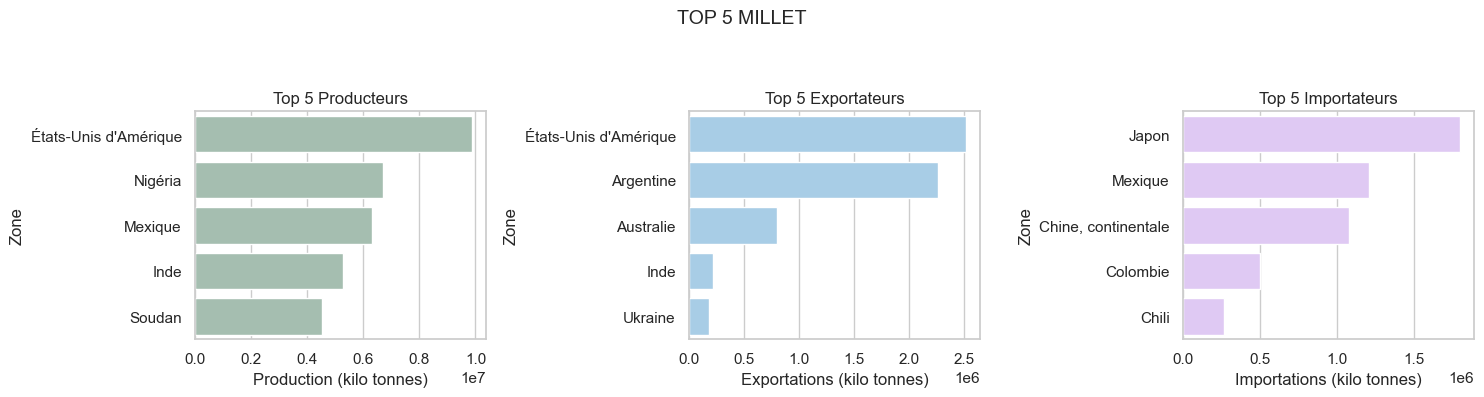

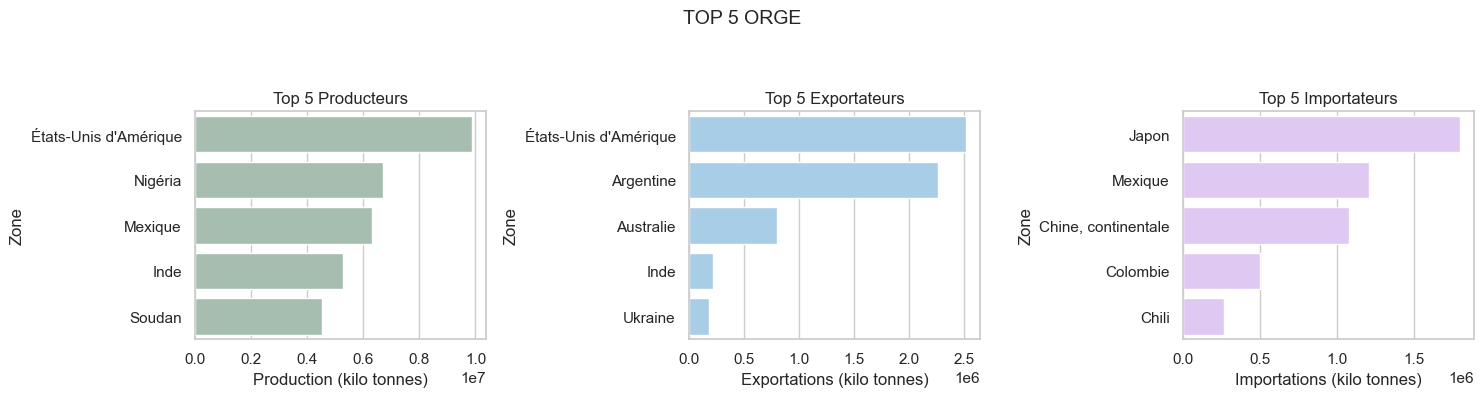

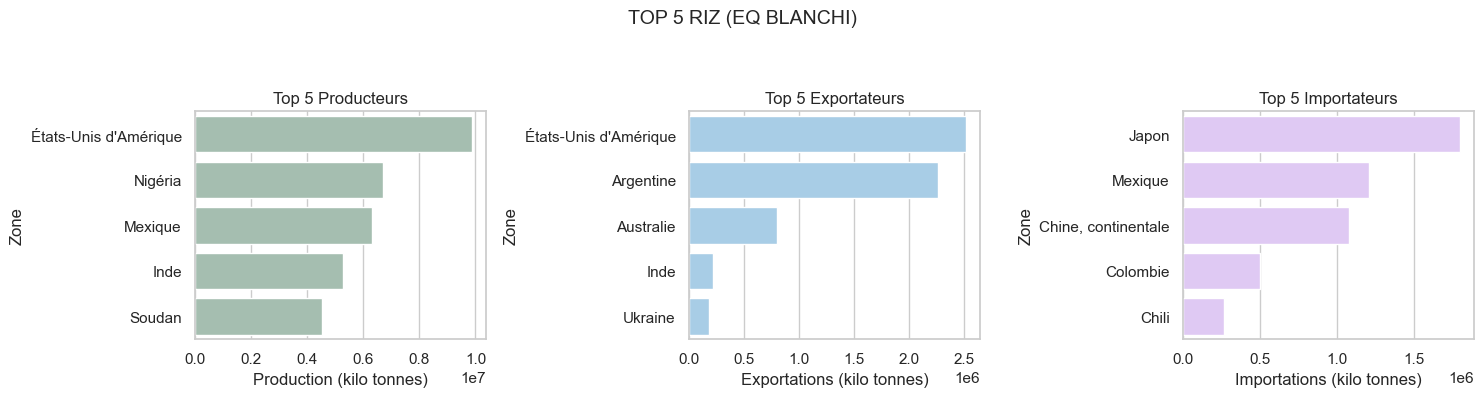

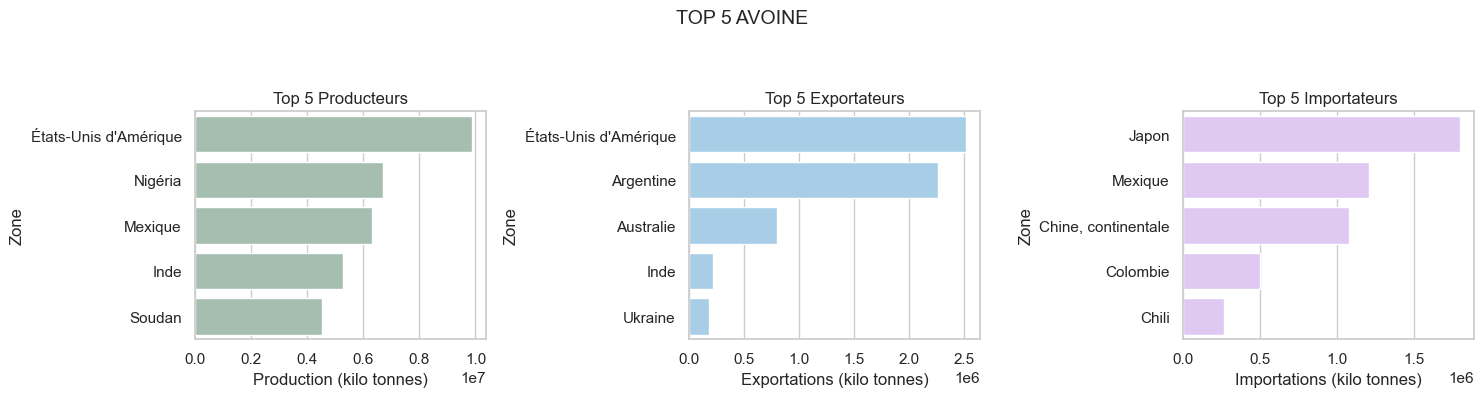

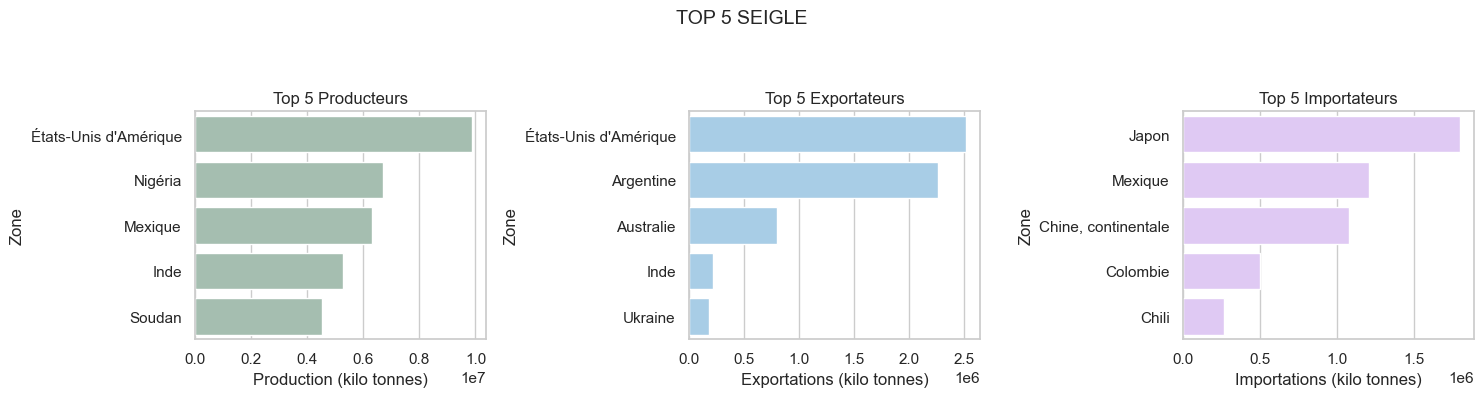

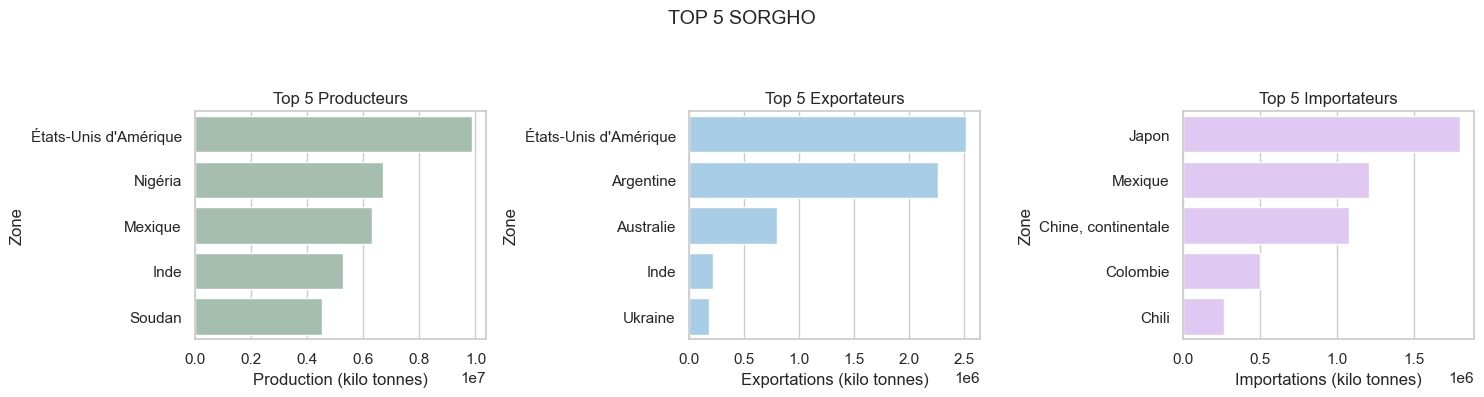

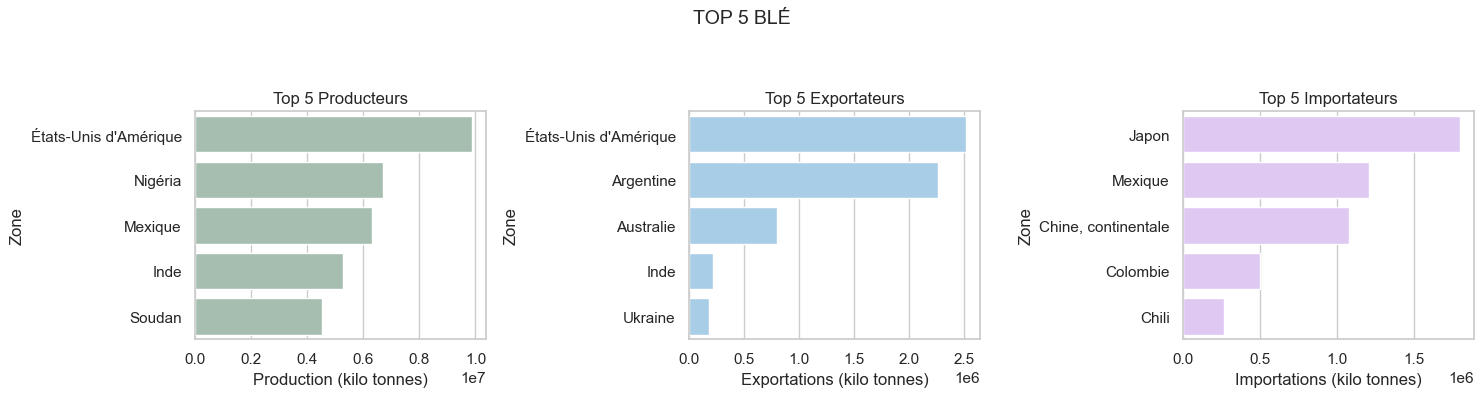

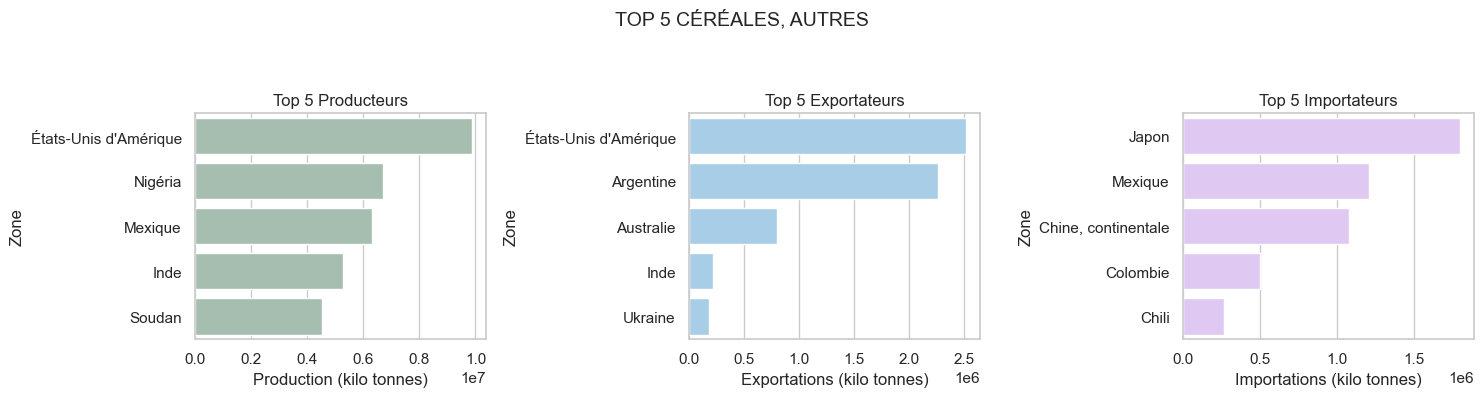

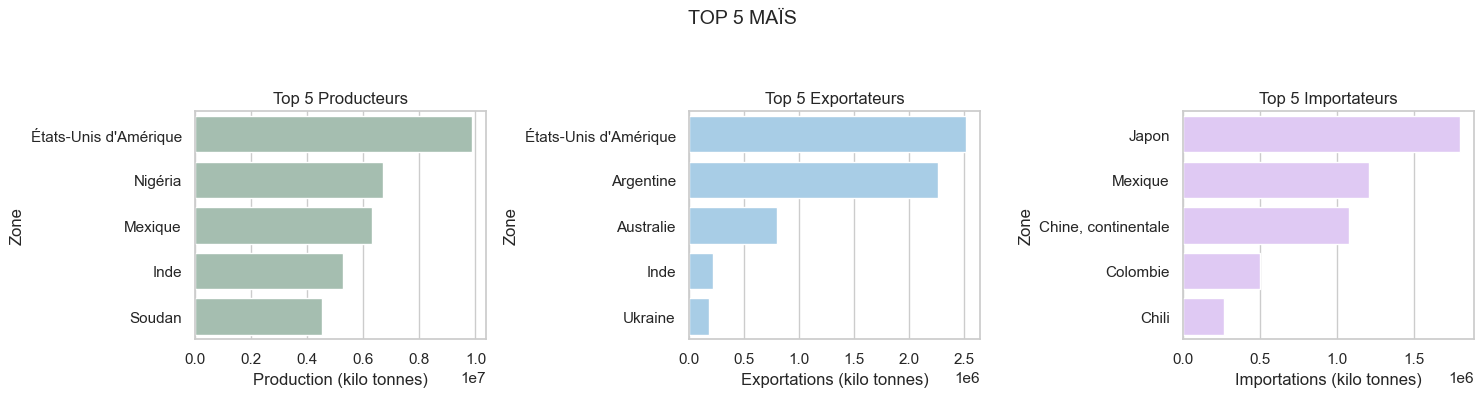

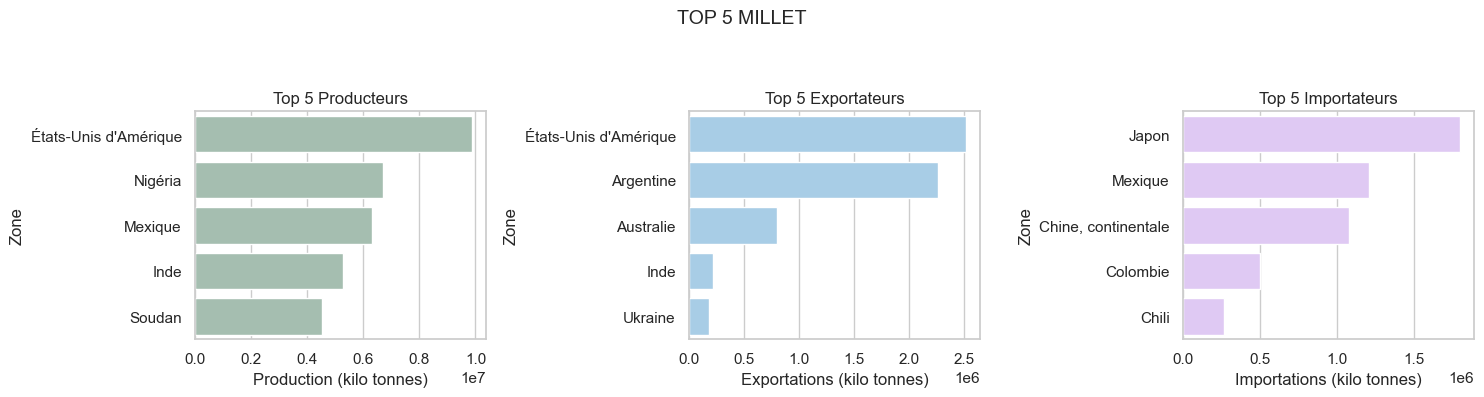

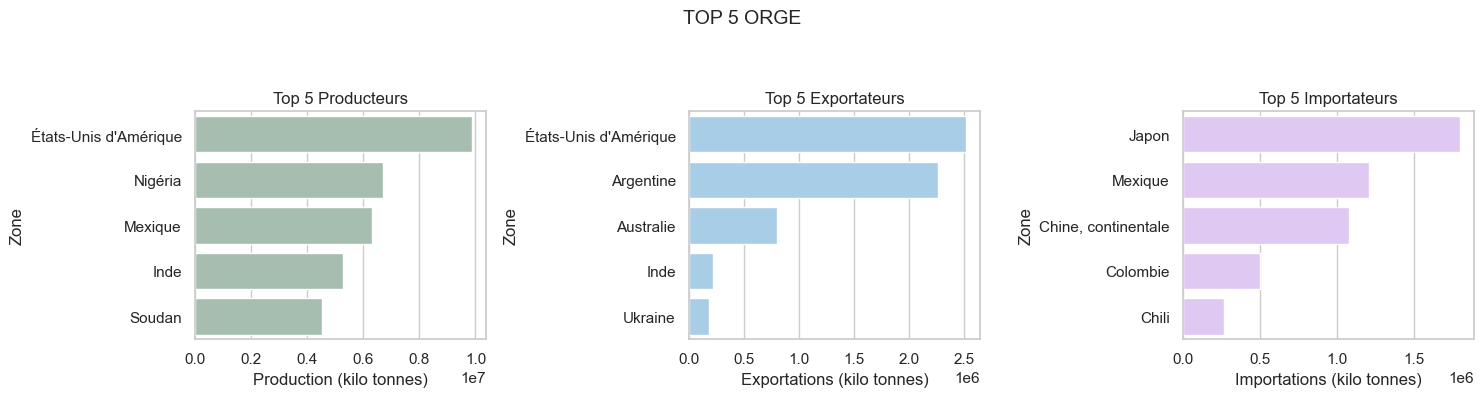

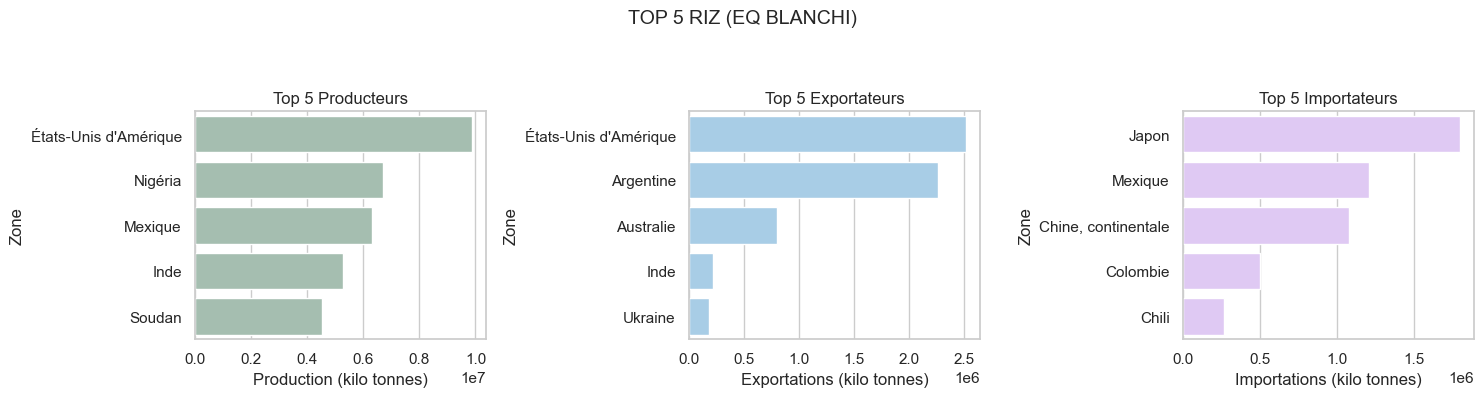

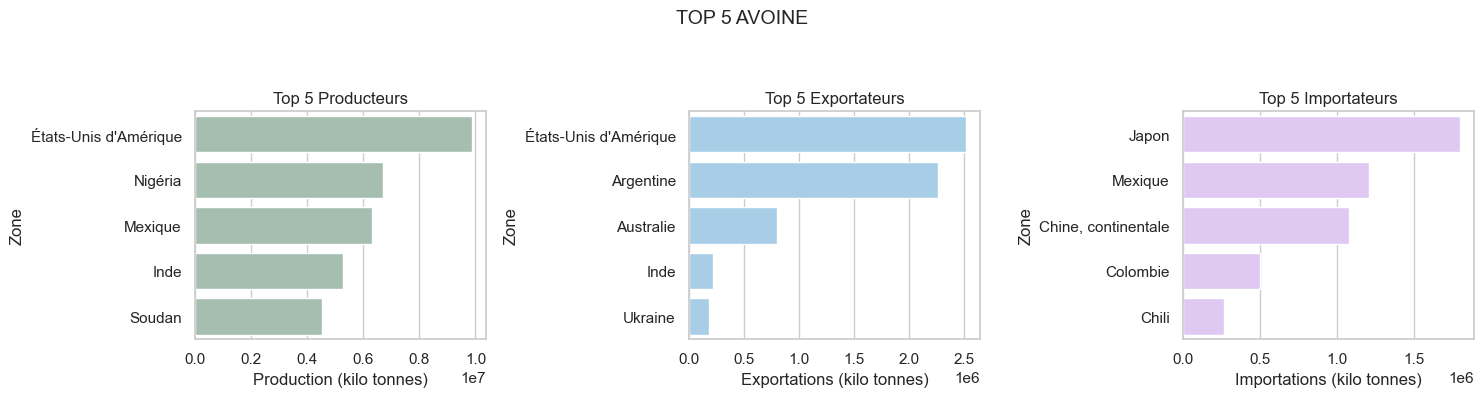

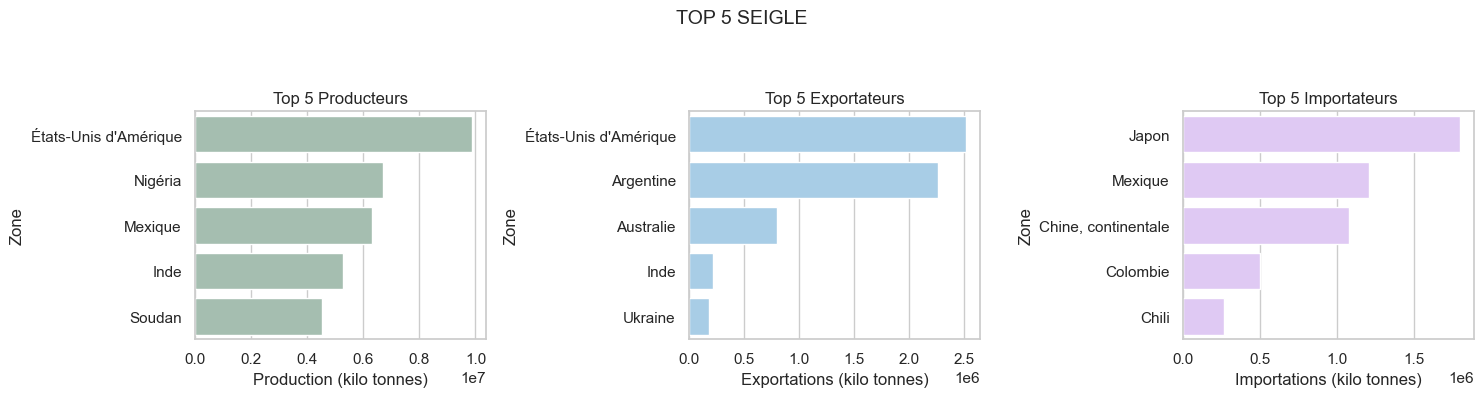

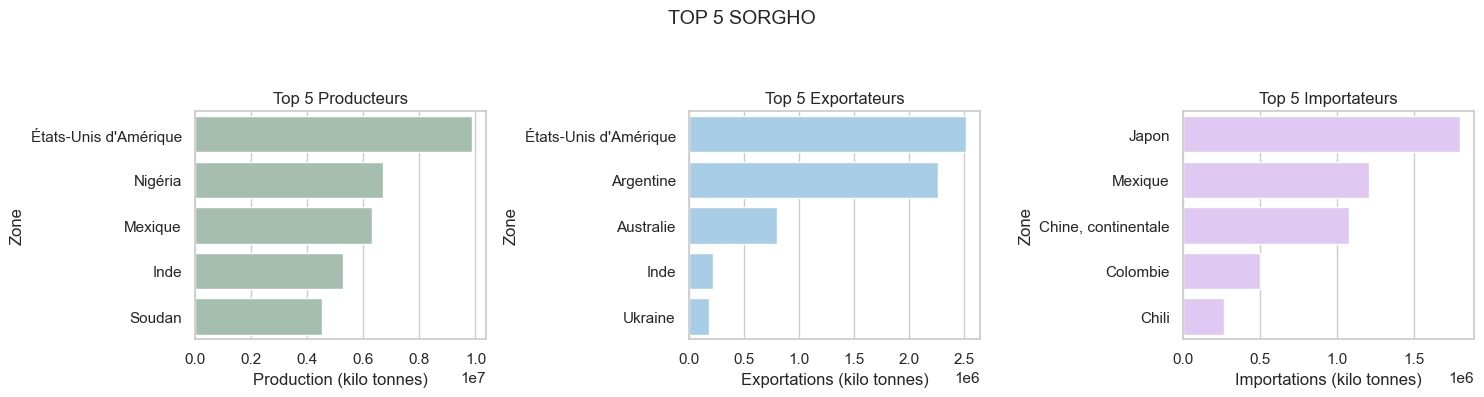

In [ ]:
# Création des graphiques pour chaques céréales

for cereale in liste_cereales:    
     
    figure, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    figure.suptitle(f'Top 5 {cereale}'.upper(), fontsize=14, y=1.02)
    
    sns.barplot(data=top5_producteurs, y="Zone", hue='Zone', x="Production_kt", ax=ax1, palette =['#a1c2af','#a1c2af','#a1c2af','#a1c2af','#a1c2af'], linewidth=1)
    ax1.set_title('Top 5 Producteurs', fontsize=12)
    ax1.set_xlabel('Production (kilo tonnes)')

    sns.barplot(data=top5_exportateurs, y="Zone", hue='Zone', x="Exportation_kt", ax=ax2, palette =['#9ecff0','#9ecff0','#9ecff0','#9ecff0','#9ecff0'], linewidth=1)
    ax2.set_title('Top 5 Exportateurs', fontsize=12)
    ax2.set_xlabel('Exportations (kilo tonnes)')
    

    sns.barplot(data=top5_importateurs, y="Zone", hue='Zone', x="Importation_kt", ax=ax3, palette =['#dfc2fa','#dfc2fa','#dfc2fa','#dfc2fa','#dfc2fa'], linewidth=1)
    ax3.set_title('Top 5 Importateurs', fontsize=12)
    ax3.set_xlabel('Importations (kilo tonnes)')

    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [ ]:
# ------------------------------------------------------------------------  ANALYSE COMPLEMENTAIRE sur le Nigéria  ------------------------------------------------------------------------

In [ ]:
# création d'un DF avec uniquement la Nigéria
da_p_nigeria = da_p.loc[da_p["Zone"] == "Nigéria"]
p_sn_nigeria = p_sn_2017.loc[p_sn_2017["Zone"] == "Nigéria"]
nigeria = pd.merge(da_p_nigeria, p_sn_nigeria, on="Zone")
nigeria.head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Semences,Traitement,Variation de stock,Année,Population_x,Dispo_kcal,Année2017p,Population_y,Sous Nutrition,Proportion par pays
0,Nigéria,Abats Comestible,animale,0.0,0.0,3.0,0.96,0.11,0.44,1.670000e+08,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,5.726197e+08,2017,190873244.0,22800000.0,11.95
1,Nigéria,"Agrumes, Autres",vegetale,0.0,0.0,13.0,18.61,0.10,0.25,3.800000e+09,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,2.481352e+09,2017,190873244.0,22800000.0,11.95
2,Nigéria,"Alcool, non Comestible",vegetale,0.0,157000000.0,0.0,0.00,0.00,0.00,1.570000e+08,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,0.000000e+00,2017,190873244.0,22800000.0,11.95
3,Nigéria,Aliments pour enfants,vegetale,0.0,0.0,0.0,0.03,0.00,0.01,6.000000e+06,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,0.000000e+00,2017,190873244.0,22800000.0,11.95
4,Nigéria,Ananas,vegetale,0.0,0.0,5.0,7.40,0.04,0.04,1.427000e+09,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,9.543662e+08,2017,190873244.0,22800000.0,11.95
5,Nigéria,Arachides Decortiquees,vegetale,0.0,125000000.0,30.0,2.03,2.49,1.29,2.109000e+09,...,116000000.0,1.374000e+09,0.0,2017.0,190873244.0,5.726197e+09,2017,190873244.0,22800000.0,11.95
6,Nigéria,Avoine,vegetale,0.0,0.0,0.0,0.03,0.00,0.01,5.000000e+06,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,0.000000e+00,2017,190873244.0,22800000.0,11.95
7,Nigéria,Bananes plantains,vegetale,0.0,0.0,39.0,16.01,0.09,0.35,2.780000e+09,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,7.444057e+09,2017,190873244.0,22800000.0,11.95
8,Nigéria,"Beurre, Ghee",animale,0.0,0.0,2.0,0.10,0.23,0.00,1.800000e+07,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,3.817465e+08,2017,190873244.0,22800000.0,11.95
9,Nigéria,Bière,vegetale,0.0,0.0,20.0,15.25,0.00,0.21,2.648000e+09,...,0.0,0.000000e+00,0.0,2017.0,190873244.0,3.817465e+09,2017,190873244.0,22800000.0,11.95


In [ ]:
# Calcul de la sous nutrition en Nigéria
nigeria_pop=nigeria['Population_x'].iloc[0]
nigeria_sn = nigeria["Sous Nutrition"].iloc[0]

print(
    f"La population totale du Nigéria est de : {nigeria_pop:,.0f} personnes".replace(
        ",", " "
    )
)
print(
    f"La quantité de personnes en état de sous-nutrition au Nigéria est de : {nigeria_sn:,.0f} personnes".replace(
        ",", " "
    )
)


La population totale du Nigéria est de : 190 873 244 personnes
La quantité de personnes en état de sous-nutrition au Nigéria est de : 22 800 000 personnes


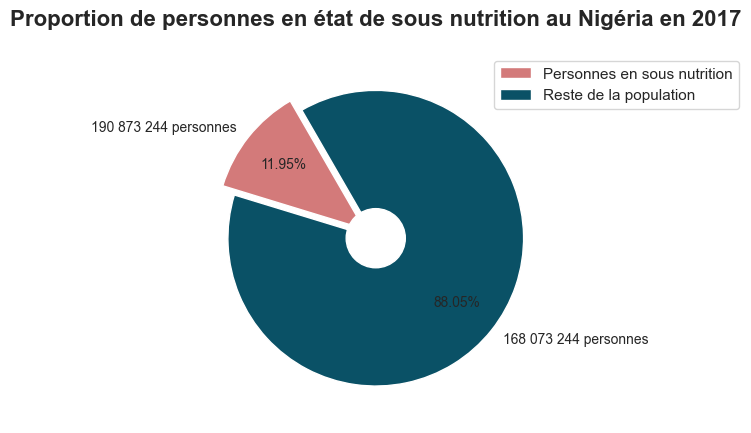

In [ ]:
# graphique représentant la part de personnes en état de sous- nutrition pour la Nigéria
plt.title(
    'Proportion de personnes en état de sous nutrition au Nigéria en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [nigeria_sn, nigeria_pop - nigeria_sn],
    labels=[
        f'{nigeria_pop:,.0f} personnes'.replace(',',' '), 
        f'{nigeria_pop - nigeria_sn:,.0f} personnes'.replace(',',' ')
    ],
    startangle=120,
    explode=[0.1, 0],
    autopct=lambda x: str(round(x, 2)) + "%",
    colors = ["#D37A7A","#0A5166"] ,
    pctdistance = 0.7, 
    textprops={'fontsize': 10}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Personnes en sous nutrition', 'Reste de la population'],     bbox_to_anchor=(0.8,1))


In [ ]:
# On calcule la proportion exportée en fonction de la Production (GLOBAL)
nigeria_export = round(((nigeria["Exportations - Quantité"].sum() / nigeria["Production"].sum())* 100),2,)

print("Le Nigeria exporte {} % de sa production totale.".format(nigeria_export))

Le Nigeria exporte 0.42 % de sa production totale.


In [ ]:
# On calcule la proportion importée en fonction de la Production (GLOBAL)
nigeria_import = round(((nigeria["Importations - Quantité"].sum() / nigeria["Production"].sum()) * 100),2,)

print("Le Nigeria importe {} % de sa production totale.".format(nigeria_import))

Le Nigeria importe 8.08 % de sa production totale.


In [ ]:
# Verification de l'absence de doublons
nigeria.duplicated().sum()

np.int64(0)

In [ ]:
# ------------------------------------------------------------------------  ANALYSE COMPLEMENTAIRE sur le Kenya  ------------------------------------------------------------------------

In [ ]:
# création d'un DF avec uniquement le Kenya
da_p_kenya = da_p.loc[da_p["Zone"] == "Kenya"]
p_sn_kenya = p_sn_2017.loc[p_sn_2017["Zone"] == "Kenya"]
kenya = pd.merge(da_p_kenya, p_sn_kenya, on="Zone")
kenya.head(10)

# Calcul de la sous nutrition au Kenya
kenya_pop=kenya['Population_x'].iloc[0]
kenya_sn = kenya["Sous Nutrition"].iloc[0]

print(f"La population totale du Kenya est de : {kenya_pop:,.0f} personnes".replace(",", " "))
print(f"La quantité de personnes en état de sous-nutrition au Kenya est de : {kenya_sn:,.0f} personnes".replace(",", " "))


La population totale du Kenya est de : 50 221 142 personnes
La quantité de personnes en état de sous-nutrition au Kenya est de : 11 900 000 personnes


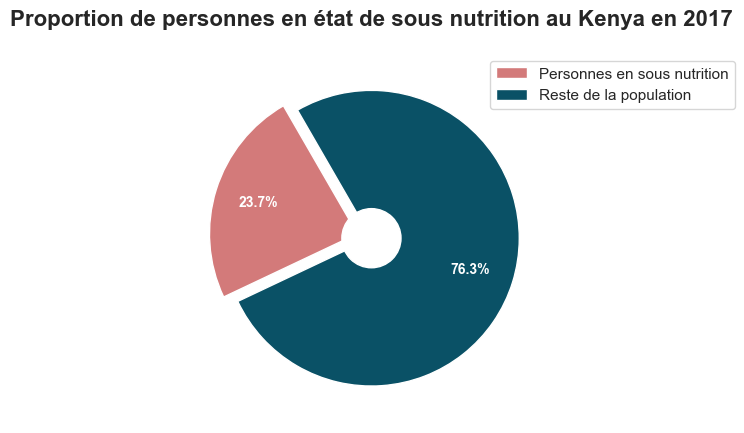

In [ ]:
# graphique représentant la part de personnes en état de sous- nutrition pour la Kenya
plt.title(
    'Proportion de personnes en état de sous nutrition au Kenya en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [kenya_sn, kenya_pop - kenya_sn],
    labels=[
        f'{kenya_pop:,.0f} personnes'.replace(',',' '), 
        f'{kenya_pop - kenya_sn:,.0f} personnes'.replace(',',' ')
    ],
    startangle=120,
    explode=[0.1, 0],
    autopct=lambda x: str(round(x, 2)) + "%",
    colors = ["#D37A7A","#0A5166"] ,
    pctdistance = 0.7, 
    textprops={'fontsize': 10, "fontweight":"bold",'color':"white"}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Personnes en sous nutrition', 'Reste de la population'],     bbox_to_anchor=(0.8,1))


In [ ]:
# On calcule la proportion exportée en fonction de la Production (GLOBAL)
kenya_export = round(
    (
        (kenya["Exportations - Quantité"].sum() / kenya["Production"].sum())
        * 100
    ),
    2,
)

print("Le Kenya exporte {} % de sa production totale.".format(kenya_export))

Le Kenya exporte 4.54 % de sa production totale.


In [ ]:
# On calcule la proportion importée en fonction de la Production (GLOBAL)
kenya_import = round(
    (
        (kenya["Importations - Quantité"].sum() / kenya["Production"].sum())
        * 100
    ),
    2,
)

print("Le Kenya importe {} % de sa production totale.".format(kenya_import))

Le Kenya importe 10.57 % de sa production totale.


In [ ]:
kenya_dispo=kenya['Disponibilité intérieure'].sum()
print(f"La disponibilité intérieure au Kenya est de : {kenya_dispo:,.0f} kg".replace(
        ",", " "
    )
)

La disponibilité intérieure au Kenya est de : 31 095 000 000 kg


In [ ]:
kenya_pertes=kenya['Pertes'].sum()
print(f"La quantité de pertes d'aliments au Kenya est de : {kenya_pertes:,.0f} kg".replace(
        ",", " "
    )
)

La quantité de pertes d'aliments au Kenya est de : 1 444 000 000 kg


In [ ]:
kenya.head(10)
Kenya_prop_pertes=round((kenya_pertes/kenya_dispo)*100,2)
print(f"Le pourcentage de pertes au Kenya est de : {Kenya_prop_pertes:,.0f} %".replace(
        ",", " "
    )
)

Le pourcentage de pertes au Kenya est de : 5 %


In [ ]:
# Verification de l'absence de doublons
kenya.duplicated().sum()

np.int64(0)

In [ ]:
kenya.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Semences,Traitement,Variation de stock,Année,Population_x,Dispo_kcal,Année2017p,Population_y,Sous Nutrition,Proportion par pays
0,Kenya,Abats Comestible,animale,0.0,0.0,5.0,1.63,0.14,0.78,72000000.0,...,0.0,0.0,0.0,2017.0,50221142.0,251105710.0,2017,50221142.0,11900000.0,23.7
1,Kenya,"Agrumes, Autres",vegetale,0.0,0.0,2.0,2.33,0.01,0.03,115000000.0,...,0.0,0.0,0.0,2017.0,50221142.0,100442284.0,2017,50221142.0,11900000.0,23.7
2,Kenya,"Alcool, non Comestible",vegetale,0.0,2000000.0,0.0,0.00,0.00,0.00,2000000.0,...,0.0,0.0,0.0,2017.0,50221142.0,0.0,2017,50221142.0,11900000.0,23.7
3,Kenya,Aliments pour enfants,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,2017.0,50221142.0,0.0,2017,50221142.0,11900000.0,23.7
4,Kenya,Ananas,vegetale,0.0,0.0,2.0,1.54,0.00,0.01,12000000.0,...,0.0,0.0,29000000.0,2017.0,50221142.0,100442284.0,2017,50221142.0,11900000.0,23.7


In [ ]:
# ----------------------------------------------------------  ANALYSE COMPLEMENTAIRE sur les pertes  -------------------------------------------------------

In [ ]:
da_p["proportion de pertes"] = round(da_p["Pertes"] / da_p["Disponibilité intérieure"] *100,2)
da_p["proportion de pertes"]=da_p["proportion de pertes"].fillna(0)
da_p.groupby("Zone")
da_p=da_p.sort_values(by="proportion de pertes", ascending=False)
da_p.head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Dispo_kcal,proportion de pertes
7308,Kenya,Ananas,vegetale,0.0,0.0,2.0,1.54,0.00,0.01,12000000.0,...,68000000.0,13000000.0,1.290000e+08,0.0,0.0,29000000.0,2017.0,50221142.0,100442284.0,108.33
3652,Costa Rica,Ananas,vegetale,0.0,0.0,33.0,29.17,0.06,0.18,460000000.0,...,142000000.0,483000000.0,2.685000e+09,0.0,0.0,72000000.0,2017.0,4949954.0,163348482.0,105.00
2871,Canada,"Plantes Oleiferes, Autre",vegetale,0.0,41000000.0,1.0,0.05,0.06,0.03,21000000.0,...,2000000.0,22000000.0,7.540000e+08,15000000.0,30000000.0,-100000000.0,2017.0,36732095.0,36732095.0,104.76
9612,Nicaragua,Café,vegetale,0.0,0.0,0.0,0.17,0.00,0.01,1000000.0,...,1000000.0,1000000.0,8.400000e+07,0.0,0.0,14000000.0,2017.0,6384846.0,0.0,100.00
13935,Togo,"Céréales, Autres",vegetale,0.0,0.0,3.0,0.43,0.02,0.07,1000000.0,...,3000000.0,1000000.0,4.000000e+06,0.0,0.0,0.0,2017.0,7698474.0,23095422.0,100.00
4436,Espagne,Pamplemousse,vegetale,0.0,0.0,0.0,0.01,0.00,0.00,1000000.0,...,0.0,1000000.0,5.900000e+07,0.0,0.0,7000000.0,2017.0,46647428.0,0.0,100.00
12904,Slovénie,Citrons & Limes,vegetale,0.0,0.0,0.0,0.21,0.00,0.00,1000000.0,...,0.0,1000000.0,0.000000e+00,0.0,0.0,0.0,2017.0,2076394.0,0.0,100.00
2733,Cameroun,Feve de Cacao,vegetale,0.0,0.0,5.0,0.51,0.42,0.11,66000000.0,...,11000000.0,55000000.0,2.750000e+08,0.0,0.0,5000000.0,2017.0,24566073.0,122830365.0,83.33
5703,Guinée-Bissau,Noix,vegetale,0.0,0.0,43.0,2.89,3.43,1.38,27000000.0,...,5000000.0,22000000.0,2.000000e+08,0.0,0.0,23000000.0,2017.0,1828145.0,78610235.0,81.48
6004,Honduras,Ananas,vegetale,0.0,0.0,2.0,2.22,0.01,0.01,88000000.0,...,18000000.0,70000000.0,1.390000e+08,0.0,0.0,0.0,2017.0,9429013.0,18858026.0,79.55


In [ ]:
# ---------------------------------------------------  ANALYSE COMPLEMENTAIRE sur le Canada  --------------------------------------------

In [ ]:
# création d'un DF avec uniquement le Canada
da_p_canada = da_p.loc[da_p["Zone"] == "Canada"]
p_sn_canada = p_sn_2017.loc[p_sn_2017["Zone"] == "Canada"]
canada = pd.merge(da_p_canada, p_sn_canada, on="Zone")
canada.head(10)

# Calcul de la sous nutrition au Canada
canada_pop= canada['Population_x'].iloc[0]
canada_sn = canada["Sous Nutrition"].iloc[0]

print(
    f"La population totale du Canada est de : {canada_pop:,.0f} personnes".replace(
        ",", " "
    )
)
print(
    f"La quantité de personnes en état de sous-nutrition au Canada est de : {canada_sn:,.0f} personnes".replace(
        ",", " "
    )
)


La population totale du Canada est de : 36 732 095 personnes
La quantité de personnes en état de sous-nutrition au Canada est de : 0 personnes


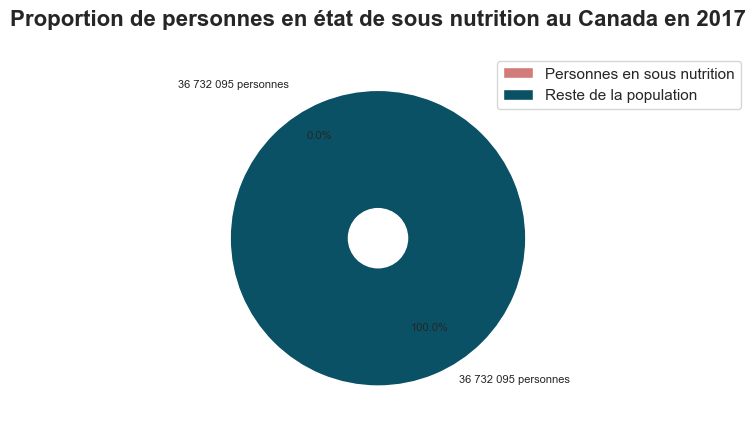

In [ ]:
# graphique représentant la part de personnes en état de sous- nutrition pour le Canada
plt.title(
    'Proportion de personnes en état de sous nutrition au Canada en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [canada_sn, canada_pop - canada_sn],
    labels=[
        f'{canada_pop:,.0f} personnes'.replace(',',' '), 
        f'{canada_pop - canada_sn:,.0f} personnes'.replace(',',' ')
    ],
    startangle=120,
    explode=[0.1, 0],
    autopct=lambda x: str(round(x, 2)) + "%",
    colors = ["#D37A7A","#0A5166"] ,
    pctdistance = 0.7, 
    textprops={'fontsize': 8}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Personnes en sous nutrition', 'Reste de la population'], bbox_to_anchor=(0.8,1))


In [ ]:
# On calcule la proportion exportée en fonction de la Production (GLOBAL)
canada_export = round(
    (
        (canada["Exportations - Quantité"].sum() / canada["Production"].sum())
        * 100
    ),
    2,
)

print("Le Canada exporte {} % de sa production totale.".format(canada_export))

Le Canada exporte 42.94 % de sa production totale.


In [ ]:
# On calcule la proportion importée en fonction de la Production (GLOBAL)
canada_import = round(
    (
        (canada["Importations - Quantité"].sum() / canada["Production"].sum())
        * 100
    ),
    2,
)

print("Le Canada importe {} % de sa production totale.".format(canada_import))

Le Canada importe 15.23 % de sa production totale.


In [ ]:
canada_dispo=canada['Disponibilité intérieure'].sum()
print(f"La disponibilité intérieure au Canada est de : {canada_dispo:,.0f} kg".replace(
        ",", " "
    )
)

La disponibilité intérieure au Canada est de : 79 562 000 000 kg


In [ ]:
canada_pertes=canada['Pertes'].sum()
print(f"La quantité de pertes d'aliments au Canada est de : {canada_pertes:,.0f} kg".replace(
        ",", " "
    )
)

La quantité de pertes d'aliments au Canada est de : 2 118 000 000 kg


In [ ]:
canada.head(10)
canada_prop_pertes=round((canada_pertes/canada_dispo)*100,2)
print(f"Le pourcentage de pertes au Canada est de : {canada_prop_pertes:,.0f} %".replace(
        ",", " "
    )
)

Le pourcentage de pertes au Canada est de : 3 %


In [ ]:
# Verification de l'absence de doublons
canada.duplicated().sum()

np.int64(0)

In [ ]:
## ------------------------------------------------------------------------  ANALYSE COMPLEMENTAIRE sur Le Costa Rica  ------------------------------------------------------------------------

In [ ]:
# création d'un dataframe avec uniquement le Costa Rica
da_p_costa_rica = da_p.loc[da_p["Zone"] == "Costa Rica"]
p_sn_costa_rica = p_sn_2017.loc[p_sn_2017["Zone"] == "Costa Rica"]
costa_rica = pd.merge(da_p_costa_rica, p_sn_costa_rica, on="Zone")
costa_rica.head(10)

# Calcul de la sous nutrition au Costa Rica
costa_rica_pop= costa_rica['Population_x'].iloc[0]
costa_rica_sn = costa_rica["Sous Nutrition"].iloc[0]

print(
    f"La population totale du Costa Rica est de : {costa_rica_pop:,.0f} personnes".replace(
        ",", " "
    )
)
print(
    f"La quantité de personnes en état de sous-nutrition au Costa Rica est de : {costa_rica_sn:,.0f} personnes".replace(
        ",", " "
    )
)


La population totale du Costa Rica est de : 4 949 954 personnes
La quantité de personnes en état de sous-nutrition au Costa Rica est de : 200 000 personnes


In [ ]:
# création d'un dataframe avec uniquement le Costa Rica
da_p_costa_rica = da_p.loc[da_p["Zone"] == "Costa Rica"]
p_sn_costa_rica = p_sn_2017.loc[p_sn_2017["Zone"] == "Costa Rica"]
costa_rica = pd.merge(da_p_costa_rica, p_sn_costa_rica, on="Zone")
costa_rica.head(10)

# Calcul de la sous nutrition au Costa Rica
costa_rica_pop= costa_rica['Population_x'].iloc[0]
costa_rica_sn = costa_rica["Sous Nutrition"].iloc[0]

print(
    f"La population totale du Costa Rica est de : {costa_rica_pop:,.0f} personnes".replace(
        ",", " "
    )
)
print(
    f"La quantité de personnes en état de sous-nutrition au Costa Rica est de : {costa_rica_sn:,.0f} personnes".replace(
        ",", " "
    )
)


La population totale du Costa Rica est de : 4 949 954 personnes
La quantité de personnes en état de sous-nutrition au Costa Rica est de : 200 000 personnes


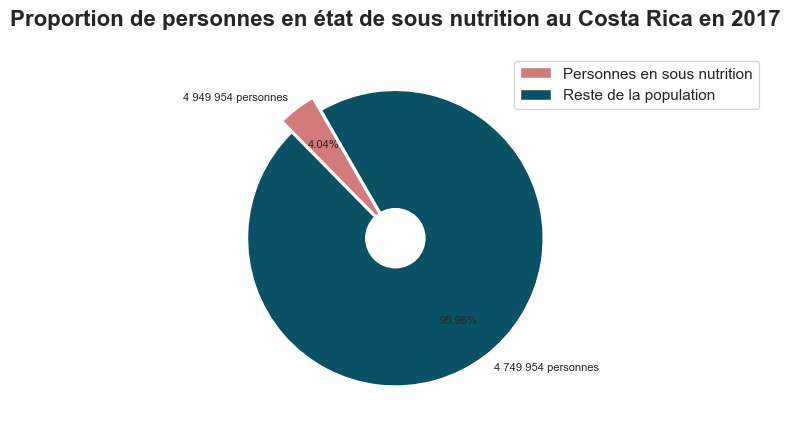

In [ ]:
# graphique représentant la part de personnes en état de sous- nutrition pour le Costa Rica
plt.title(
    'Proportion de personnes en état de sous nutrition au Costa Rica en 2017',
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.pie(
    [costa_rica_sn, costa_rica_pop - costa_rica_sn],
    labels=[
        f'{costa_rica_pop:,.0f} personnes'.replace(',',' '), 
        f'{costa_rica_pop - costa_rica_sn:,.0f} personnes'.replace(',',' ')
    ],
    startangle=120,
    explode=[0.1, 0],
    autopct=lambda x: str(round(x, 2)) + "%",
    colors = ["#D37A7A","#0A5166"] ,
    pctdistance = 0.7, 
    textprops={'fontsize': 8}
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.legend(['Personnes en sous nutrition', 'Reste de la population'],     bbox_to_anchor=(0.8,1))


In [ ]:
# On calcule la proportion exportée en fonction de la Production (GLOBAL)
costa_rica_export = round(
    (
        (costa_rica["Exportations - Quantité"].sum() / costa_rica["Production"].sum())
        * 100
    ),
    2,
)

print("Le Costa Rica exporte {} % de sa production totale.".format(costa_rica_export))

Le Costa Rica exporte 44.92 % de sa production totale.


In [ ]:
# On calcule la proportion importée en fonction de la Production (GLOBAL)
costa_rica_import = round(
    (
        (costa_rica["Importations - Quantité"].sum() / costa_rica["Production"].sum())
        * 100
    ),
    2,
)

print("Le Costa Rica importe {} % de sa production totale.".format(costa_rica_import))

Le Costa Rica importe 14.99 % de sa production totale.


In [ ]:
# Calcul de la disponibilité intérieure
costa_rica_dispo=costa_rica['Disponibilité intérieure'].sum()
print(f"La disponibilité intérieure au Costa Rica est de : {costa_rica_dispo:,.0f} kg".replace(
        ",", " "
    )
)

La disponibilité intérieure au Costa Rica est de : 10 049 000 000 kg


In [ ]:
# Calcul des pertes
costa_rica_pertes=costa_rica['Pertes'].sum()
print(f"La quantité de pertes d'aliments au Costa Rica est de : {costa_rica_pertes:,.0f} kg".replace(
        ",", " "
    )
)

La quantité de pertes d'aliments au Costa Rica est de : 1 058 000 000 kg


In [ ]:
# Pourcentage de perte
costa_rica.head(10)
costa_rica_prop_pertes=round((costa_rica_pertes/costa_rica_dispo)*100,2)
print(f"Le pourcentage de pertes au Costa Rica est de : {costa_rica_prop_pertes:,.0f} %".replace(
        ",", " "
    )
)

Le pourcentage de pertes au Costa Rica est de : 11 %


In [ ]:
# Verification de l'absence de doublons
costa_rica.duplicated().sum()

np.int64(0)